In [1]:
import pandas as pd

file_path = 'df_prop_binario.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda,y_bin,classe_risco_qualificacao
0,5197734,1421.0,2,35,52403,0,2,1,1,1,...,0.0,0,0,0.0,0.0,0.000000,0.5,2,1,renda formal per capita (CNIS) > ½ SM
1,3623103,178.0,2,31,47907,0,2,1,1,1,...,0.0,0,0,0.0,0.0,0.500000,0.0,0,0,renda formal per capita (CNIS) ≤ ½ SM
2,1772091,253.0,2,26,10608,0,1,1,1,2,...,0.0,0,0,0.0,0.0,0.000000,0.0,1,0,renda formal per capita (CNIS) ≤ ½ SM
3,7938174,276.0,2,52,17609,0,1,1,1,1,...,1.0,0,0,0.0,0.0,0.000000,0.0,1,0,renda formal per capita (CNIS) ≤ ½ SM
4,5030351,5888.0,2,35,50308,0,3,1,1,1,...,0.0,0,0,0.0,0.0,0.333333,0.0,2,1,renda formal per capita (CNIS) > ½ SM


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 54 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   VL_RENDA_MEDIA_FAM            1000000 non-null  float64
 2   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 3   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 4   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 5   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 6   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 7   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 8   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 9   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 10  QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 11  QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 12  CO_MATERIAL_DOMIC_FAM         1000000 no

In [4]:
import pandas as pd

# ── 1) Presença do código 53 no df original ───────────────────────────────────
col = "CO_MUNIC_IBGE_2_FAM"

ufs_presentes = sorted(df[col].dropna().unique().astype(int).tolist())
print(f"UFs presentes no df original ({len(ufs_presentes)}):")
print(ufs_presentes)

ufs_esperadas = {
    11, 12, 13, 14, 15, 16, 17,
    21, 22, 23, 24, 25, 26, 27, 28, 29,
    31, 32, 33, 35,
    41, 42, 43,
    50, 51, 52, 53,
}
ufs_faltantes = ufs_esperadas - set(ufs_presentes)
print(f"\nUFs faltantes: {sorted(ufs_faltantes) if ufs_faltantes else 'Nenhuma — todas as 27 presentes'}")

# ── 2) Volume por UF ──────────────────────────────────────────────────────────
UF_SIGLA = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA",
    31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS",
    50: "MS", 51: "MT", 52: "GO", 53: "DF",
}

resumo = (
    df[col].value_counts()
    .rename_axis("codigo")
    .reset_index(name="N")
    .assign(
        codigo=lambda x: x["codigo"].astype(int),
        UF=lambda x: x["codigo"].map(UF_SIGLA).fillna("?"),
        pct=lambda x: (x["N"] / x["N"].sum() * 100).round(2),
    )
    .sort_values("codigo")
    [["codigo", "UF", "N", "pct"]]
    .reset_index(drop=True)
)
resumo["N"]   = resumo["N"].map("{:,}".format)
resumo["pct"] = resumo["pct"].map("{:.2f}%".format)

print(f"\nVolume por UF no df original (total: {len(df):,} linhas):")
display(resumo)

# ── 3) Se 53 existe mas com volume baixo ─────────────────────────────────────
n_df = (df[col] == 53).sum()
print(f"\nLinhas com código 53 (DF) no df original: {n_df:,}")

# ── 4) Rastrear se o filtro SQL removeu o DF ─────────────────────────────────
print("\nParâmetros de filtro usados na query:")
print(f"  munic2_ini = {munic2_ini if 'munic2_ini' in dir() else 'não definido'}")
print(f"  munic2_fim = {munic2_fim if 'munic2_fim' in dir() else 'não definido'}")
if 'munic2_ini' in dir() and 'munic2_fim' in dir():
    print(f"  53 dentro do intervalo [{munic2_ini}, {munic2_fim}]: {munic2_ini <= 53 <= munic2_fim}")

UFs presentes no df original (27):
[11, 12, 13, 14, 15, 16, 17, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 35, 41, 42, 43, 50, 51, 52, 53]

UFs faltantes: Nenhuma — todas as 27 presentes

Volume por UF no df original (total: 1,000,000 linhas):


,codigo,UF,N,pct
0,11,RO,"8,743",0.87%
1,12,AC,"4,138",0.41%
2,13,AM,"16,662",1.67%
3,14,RR,"2,974",0.30%
4,15,PA,"35,697",3.57%
5,16,AP,"3,192",0.32%
6,17,TO,"9,433",0.94%
7,21,MA,"23,885",2.39%
8,22,PI,"16,612",1.66%
9,23,CE,"47,016",4.70%



Linhas com código 53 (DF) no df original: 12,307

Parâmetros de filtro usados na query:
  munic2_ini = não definido
  munic2_fim = não definido


In [5]:
(df["CO_PRINCIPAL_TRAB_MEMB"] == 9).any()

np.True_

In [6]:
(df["CO_PRINCIPAL_TRAB_MEMB"] == 9).sum()

np.int64(242)

In [7]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [9]:
df['classe_renda'].info()

<class 'pandas.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [10]:
df['y_bin'].info()

<class 'pandas.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: y_bin
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


## Separação treino e teste

In [11]:
df["ID_FAM_ANON"].is_unique

True

In [12]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [13]:
colunas_excluir = [
    "classe_renda",
    "y_bin",
    "classe_risco_qualificacao",
    "VL_RENDA_MEDIA_FAM",
    "ID_FAM_ANON"
]

X = df.drop(columns=colunas_excluir)
y = df["y_bin"]


In [14]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [15]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1

## Análise de correlação das variáveis

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
    'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
    'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

In [17]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


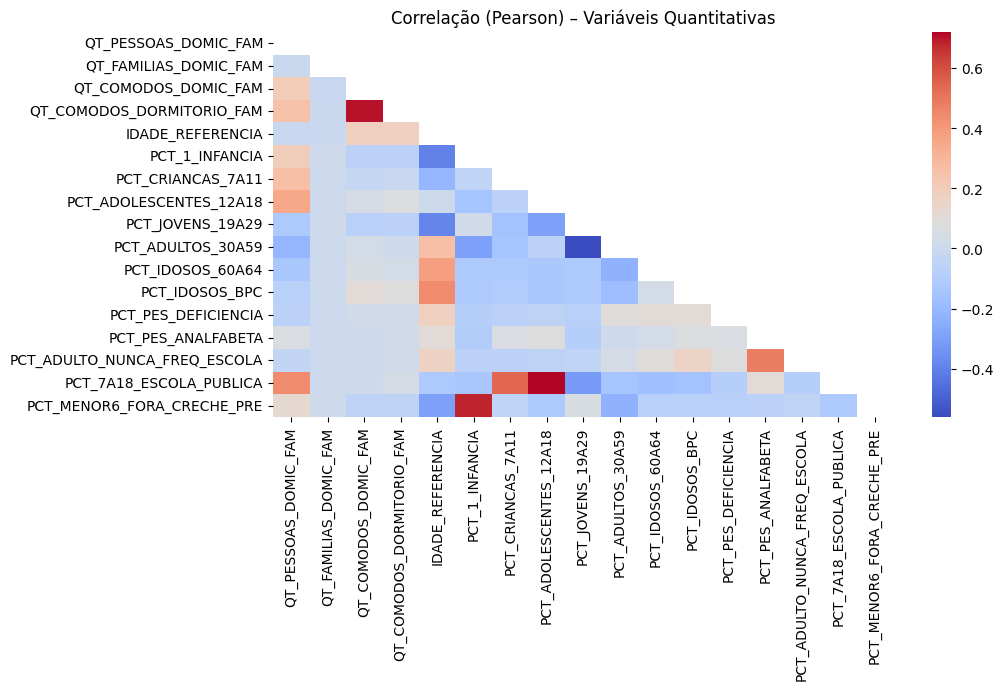

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = X[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()

In [19]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
134,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.715935
37,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.698638
101,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.682823
145,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.564747
117,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.540172
235,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.483242
79,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.442998
15,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.439084
73,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.398539
76,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.388439


In [20]:
THR_CORR = 0.80

corr_fortes = corr_pairs_sorted[
    corr_pairs_sorted["corr"].abs() >= THR_CORR
].copy()

corr_fortes

,var1,var2,corr


In [21]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


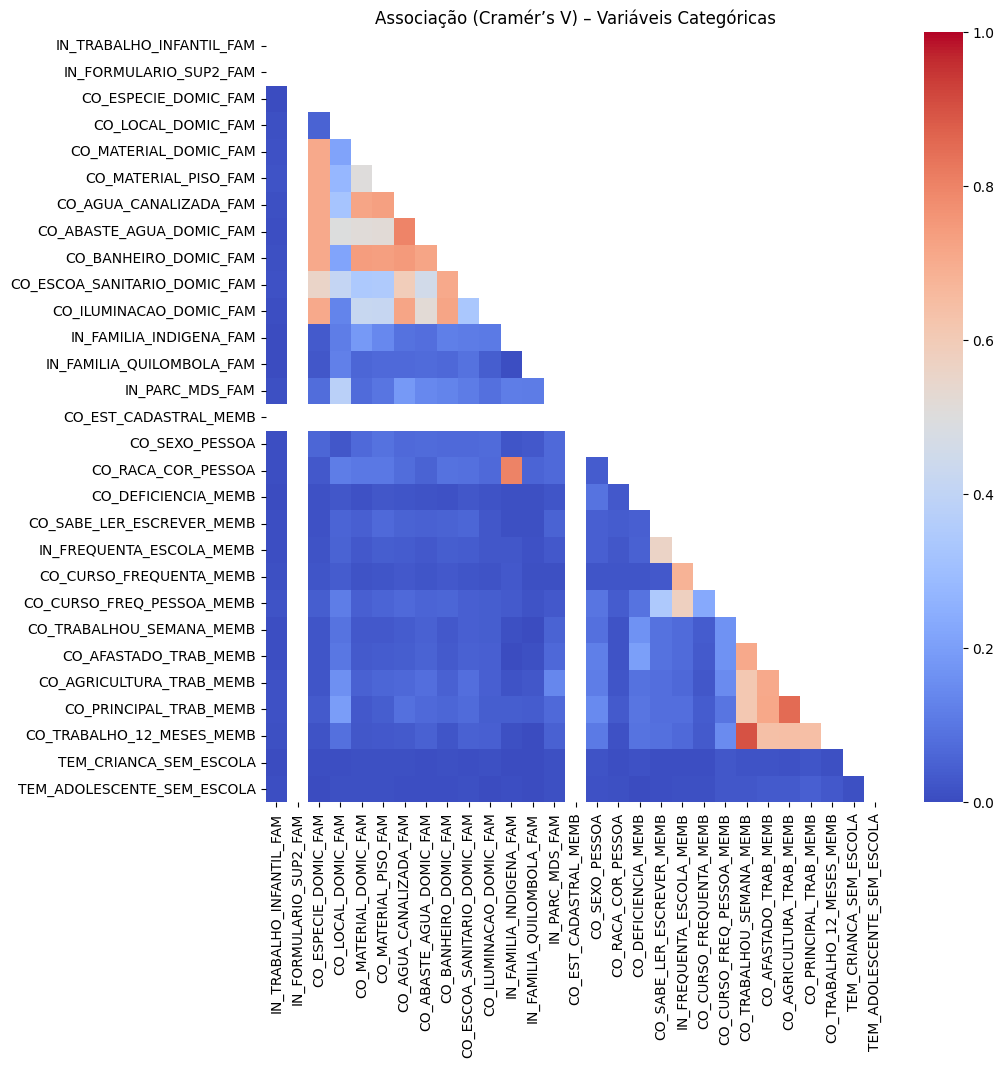

In [22]:
# Selecionar todas as categóricas
df_cat = X[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [23]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
664  CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900383
721  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.852669
335   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.800995
181    CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.796955
182    CO_AGUA_CANALIZADA_FAM      CO_BANHEIRO_DOMIC_FAM   0.746949
124     CO_MATERIAL_DOMIC_FAM      CO_BANHEIRO_DOMIC_FAM   0.740447
153      CO_MATERIAL_PISO_FAM      CO_BANHEIRO_DOMIC_FAM   0.737158
151      CO_MATERIAL_PISO_FAM     CO_AGUA_CANALIZADA_FAM   0.730719
211  CO_ABASTE_AGUA_DOMIC_FAM      CO_BANHEIRO_DOMIC_FAM   0.722457
122     CO_MATERIAL_DOMIC_FAM     CO_AGUA_CANALIZADA_FAM   0.721716


In [24]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
664  CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900383
721  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.852669
335   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.800995


In [25]:
X = X.drop(columns=['CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM'])

In [26]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT

In [27]:
X.head()

,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE
0,2,35,52403,0,2,1,1,1,5,2,...,0.500000,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.5
1,2,31,47907,0,2,1,1,1,5,2,...,0.500000,0.0,0.0,0.0,0,0,0.0,0.0,0.500000,0.0
2,2,26,10608,0,1,1,1,2,4,1,...,0.000000,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.0
3,2,52,17609,0,1,1,1,1,2,1,...,0.000000,0.0,0.0,1.0,0,0,0.0,0.0,0.000000,0.0
4,2,35,50308,0,3,1,1,1,6,2,...,0.666667,0.0,0.0,0.0,0,0,0.0,0.0,0.333333,0.0


In [28]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 46 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 1   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 2   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 3   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 5   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 6   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 7   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 8   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 10  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          1000000 non-null  int64  
 12  CO_AGUA_CANALIZADA_FAM        1000000 no

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [29]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT

In [30]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 
    'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'QTD_PESSOAS', 'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']


In [31]:
# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'CO_LOCAL_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB']


In [32]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
   ("scale", MinMaxScaler()),
])

In [33]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [34]:
# Pipeline para binárias
pipeline_binary = "passthrough"

In [35]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [36]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [37]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [38]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [40]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quant', ...), ('pct', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [41]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__QTD_PESSOAS,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,...,multicat__CO_PRINCIPAL_TRAB_MEMB_7,multicat__CO_PRINCIPAL_TRAB_MEMB_8,multicat__CO_PRINCIPAL_TRAB_MEMB_9,multicat__CO_PRINCIPAL_TRAB_MEMB_10,multicat__CO_PRINCIPAL_TRAB_MEMB_11,multicat__CO_TRABALHO_12_MESES_MEMB_-1,multicat__CO_TRABALHO_12_MESES_MEMB_1,multicat__CO_TRABALHO_12_MESES_MEMB_2,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.076923,0.010101,0.030928,0.021739,0.076923,0.233333,0.000000,0.0,0.5,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.0,36306.0
1,0.076923,0.010101,0.061856,0.032609,0.076923,0.344444,0.000000,0.0,0.5,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,35.0,3802.0
2,0.307692,0.010101,0.072165,0.032609,0.307692,0.244444,0.200000,0.0,0.4,0.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,6603.0
3,0.076923,0.010101,0.061856,0.032609,0.076923,0.233333,0.500000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.0,56700.0
4,0.153846,0.010101,0.072165,0.043478,0.153846,0.333333,0.333333,0.0,0.0,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33.0,4557.0


### Comparando diversos modelos

In [42]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
!pip install catboost --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ------------------------------------------------------------
# 0) CONFIG DE TRIAGEM
# ------------------------------------------------------------
SEED = 42
THRESHOLD_TRIAGEM = 0.80  # ajuste depois conforme capacidade operacional
POS_LABEL = 1             # 1 = acima de 1/2 SM (potencialmente não elegível)


# ------------------------------------------------------------
# 1) MODELOS (ajustados para BINÁRIO)
# ------------------------------------------------------------
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        random_state=SEED
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"  # ajuda quando há desbalanceamento
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=1200,          # mais árvores + taxa menor costuma ajudar
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1
        # (opcional) scale_pos_weight pode ser ajustado se a classe 1 for rara
    ),

    "CatBoost": CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False
        # (opcional) class_weights=[w0, w1] se necessário
    ),
}


# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (com métricas para TRIAGEM)
# ------------------------------------------------------------
pipes = {}
results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    # Predição padrão (threshold 0.5)
    y_pred_05 = pipe.predict(X_test).ravel()

    # Probabilidades (para AUC/PR-AUC e para threshold de triagem)
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    # Predição para TRIAGEM (threshold configurável)
    if y_proba is not None:
        y_pred_t = (y_proba >= THRESHOLD_TRIAGEM).astype(int)
    else:
        y_pred_t = y_pred_05  # fallback

    # -------------------------
    # Métricas: padrão 0.5
    # -------------------------
    acc_05 = accuracy_score(y_test, y_pred_05)
    balacc_05 = balanced_accuracy_score(y_test, y_pred_05)

    prec_05 = precision_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    rec_05  = recall_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    f1_05   = f1_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)

    tn05, fp05, fn05, tp05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1]).ravel()

    # -------------------------
    # Métricas: TRIAGEM (threshold = THRESHOLD_TRIAGEM)
    # -------------------------
    acc_t = accuracy_score(y_test, y_pred_t)
    balacc_t = balanced_accuracy_score(y_test, y_pred_t)

    prec_t = precision_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    f1_t   = f1_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)

    tnt, fpt, fnt, tpt = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()

    # -------------------------
    # AUC / PR-AUC (se houver proba)
    # -------------------------
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)  # PR-AUC (muito útil p/ triagem)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # "Taxa de convocação" no teste (volume relativo gerado pela regra)
    convoc_rate = float(np.mean(y_pred_t == 1))

    results.append({
        "modelo": name,

        # Ranking mais aderente ao objetivo de triagem
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,

        # Métricas com threshold padrão
        "acc@0.50": acc_05,
        "bal_acc@0.50": balacc_05,
        "prec_pos@0.50": prec_05,
        "rec_pos@0.50": rec_05,
        "f1_pos@0.50": f1_05,
        "tp@0.50": tp05, "fp@0.50": fp05, "fn@0.50": fn05, "tn@0.50": tn05,

        # Métricas para a regra operacional de triagem
        f"acc@{THRESHOLD_TRIAGEM:.2f}": acc_t,
        f"bal_acc@{THRESHOLD_TRIAGEM:.2f}": balacc_t,
        f"prec_pos@{THRESHOLD_TRIAGEM:.2f}": prec_t,
        f"rec_pos@{THRESHOLD_TRIAGEM:.2f}": rec_t,
        f"f1_pos@{THRESHOLD_TRIAGEM:.2f}": f1_t,
        f"tp@{THRESHOLD_TRIAGEM:.2f}": tpt, f"fp@{THRESHOLD_TRIAGEM:.2f}": fpt,
        f"fn@{THRESHOLD_TRIAGEM:.2f}": fnt, f"tn@{THRESHOLD_TRIAGEM:.2f}": tnt,

        # volume gerado
        f"taxa_convocacao@{THRESHOLD_TRIAGEM:.2f}": convoc_rate,
    })


# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = (
    pd.DataFrame(results)
      .sort_values(["pr_auc", "roc_auc"], ascending=False)
      .reset_index(drop=True)
)

df_results



Treinando modelo: LogisticRegression


D:\JupyterLab\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\JupyterLab\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Treinando modelo: RandomForest

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,pr_auc,roc_auc,acc@0.50,bal_acc@0.50,prec_pos@0.50,rec_pos@0.50,f1_pos@0.50,tp@0.50,fp@0.50,...,acc@0.80,bal_acc@0.80,prec_pos@0.80,rec_pos@0.80,f1_pos@0.80,tp@0.80,fp@0.80,fn@0.80,tn@0.80,taxa_convocacao@0.80
0,XGBoost,0.846210,0.825609,0.751050,0.740437,0.748334,0.833392,0.788576,92854,31227,...,0.620045,0.653368,0.892506,0.361498,0.514574,40277,4851,71140,83732,0.225640
1,CatBoost,0.844126,0.823719,0.749880,0.739380,0.747834,0.831345,0.787382,92626,31233,...,0.613800,0.647992,0.892993,0.348511,0.501356,38830,4653,72587,83930,0.217415
2,HistGradientBoosting,0.842511,0.821887,0.748135,0.737279,0.745283,0.832368,0.786422,92740,31696,...,0.611480,0.645962,0.892660,0.343942,0.496560,38321,4608,73096,83975,0.214645
3,RandomForest,0.816737,0.799465,0.727900,0.723253,0.751667,0.763959,0.757763,85118,28121,...,0.601645,0.635703,0.865434,0.337390,0.485506,37591,5845,73826,82738,0.217180
4,LogisticRegression,0.813907,0.793846,0.725660,0.719311,0.743475,0.774918,0.758871,86339,29790,...,0.599120,0.633121,0.859282,0.335308,0.482381,37359,6118,74058,82465,0.217385


In [45]:
import pandas as pd

# ── Colunas de interesse ──────────────────────────────────────────────────────
cols_050 = {
    "prec_pos@0.50"  : "precision_pos",
    "rec_pos@0.50"   : "recall_pos",
    "f1_pos@0.50"    : "f1_pos",
    "tp@0.50"        : "tp",
    "fp@0.50"        : "fp",
    "fn@0.50"        : "fn",
    "tn@0.50"        : "tn",
}
cols_080 = {
    "prec_pos@0.80"  : "precision_pos",
    "rec_pos@0.80"   : "recall_pos",
    "f1_pos@0.80"    : "f1_pos",
    "tp@0.80"        : "tp",
    "fp@0.80"        : "fp",
    "fn@0.80"        : "fn",
    "tn@0.80"        : "tn",
    "taxa_convocacao@0.80": "taxa_convocacao",
}

# ── Montar tabela comparativa ─────────────────────────────────────────────────
linhas = []
for _, row in df_results.iterrows():
    for thr, cols in [("0.50", cols_050), ("0.80", cols_080)]:
        linha = {
            "modelo"   : row["modelo"],
            "threshold": float(thr),
            "pr_auc"   : row.get("pr_auc",  None),   # ← adicionado
            "roc_auc"  : row.get("roc_auc", None),   # ← adicionado
        }
        for col_orig, col_novo in cols.items():
            linha[col_novo] = row.get(col_orig, None)
        if thr == "0.50":
            total = linha["tp"] + linha["fp"] + linha["fn"] + linha["tn"]
            linha["taxa_convocacao"] = (linha["tp"] + linha["fp"]) / total if total > 0 else 0
        linhas.append(linha)

tab = pd.DataFrame(linhas)

# ── Ordenar: threshold 0.80 primeiro, depois 0.50 ────────────────────────────
tab = tab.sort_values(
    ["threshold", "precision_pos"],
    ascending=[False, False]
).reset_index(drop=True)

# ── Tabela completa ───────────────────────────────────────────────────────────
print("=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===\n")
display(tab)

# ── Tabela de triagem (threshold=0.80 apenas) ─────────────────────────────────
print("\n=== Tabela de triagem (threshold=0.80) ===\n")
tab_triagem = (
    tab[tab["threshold"] == 0.80]
    .sort_values("recall_pos", ascending=False)
    .reset_index(drop=True)
)
display(
    tab_triagem.style
    .format({
        "pr_auc"         : "{:.4f}",
        "roc_auc"        : "{:.4f}",
        "precision_pos"  : "{:.4f}",
        "recall_pos"     : "{:.4f}",
        "f1_pos"         : "{:.4f}",
        "tp"             : "{:,.0f}",
        "fp"             : "{:,.0f}",
        "fn"             : "{:,.0f}",
        "tn"             : "{:,.0f}",
        "taxa_convocacao": "{:.4f}",
    })
    .highlight_max(
        subset=["pr_auc", "roc_auc", "precision_pos", "recall_pos", "f1_pos"],
        color="#c6efce"
    )
    .highlight_min(subset=["taxa_convocacao"], color="#ffeb9c")
    .set_properties(**{"text-align": "center", "padding": "6px 12px"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("text-align", "center"),
            ("background-color", "#f0f0f0"),
            ("font-weight", "bold")
        ]},
    ])
)


=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===



,modelo,threshold,pr_auc,roc_auc,precision_pos,recall_pos,f1_pos,tp,fp,fn,tn,taxa_convocacao
0,CatBoost,0.8,0.844126,0.823719,0.892993,0.348511,0.501356,38830,4653,72587,83930,0.217415
1,HistGradientBoosting,0.8,0.842511,0.821887,0.892660,0.343942,0.496560,38321,4608,73096,83975,0.214645
2,XGBoost,0.8,0.846210,0.825609,0.892506,0.361498,0.514574,40277,4851,71140,83732,0.225640
3,RandomForest,0.8,0.816737,0.799465,0.865434,0.337390,0.485506,37591,5845,73826,82738,0.217180
4,LogisticRegression,0.8,0.813907,0.793846,0.859282,0.335308,0.482381,37359,6118,74058,82465,0.217385
5,RandomForest,0.5,0.816737,0.799465,0.751667,0.763959,0.757763,85118,28121,26299,60462,0.566195
6,XGBoost,0.5,0.846210,0.825609,0.748334,0.833392,0.788576,92854,31227,18563,57356,0.620405
7,CatBoost,0.5,0.844126,0.823719,0.747834,0.831345,0.787382,92626,31233,18791,57350,0.619295
8,HistGradientBoosting,0.5,0.842511,0.821887,0.745283,0.832368,0.786422,92740,31696,18677,56887,0.622180
9,LogisticRegression,0.5,0.813907,0.793846,0.743475,0.774918,0.758871,86339,29790,25078,58793,0.580645



=== Tabela de triagem (threshold=0.80) ===



,modelo,threshold,pr_auc,roc_auc,precision_pos,recall_pos,f1_pos,tp,fp,fn,tn,taxa_convocacao
0,XGBoost,0.800000,0.8462,0.8256,0.8925,0.3615,0.5146,"40,277","4,851","71,140","83,732",0.2256
1,CatBoost,0.800000,0.8441,0.8237,0.8930,0.3485,0.5014,"38,830","4,653","72,587","83,930",0.2174
2,HistGradientBoosting,0.800000,0.8425,0.8219,0.8927,0.3439,0.4966,"38,321","4,608","73,096","83,975",0.2146
3,RandomForest,0.800000,0.8167,0.7995,0.8654,0.3374,0.4855,"37,591","5,845","73,826","82,738",0.2172
4,LogisticRegression,0.800000,0.8139,0.7938,0.8593,0.3353,0.4824,"37,359","6,118","74,058","82,465",0.2174


In [46]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Modelos que você quer comparar
modelos_alvo = ["XGBoost", "HistGradientBoosting", "CatBoost"]

POS_LABEL = 1                  # 1 = acima de 1/2 SM
THRESHOLDS = [0.50, 0.80]       # padrão e triagem

rows = []

for nome in modelos_alvo:
    pipe = pipes[nome]

    # Probabilidades para usar thresholds
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    for thr in THRESHOLDS:
        if y_proba is None:
            # fallback: usa predict padrão (equivalente a 0.5)
            if thr != 0.50:
                continue
            y_pred = pipe.predict(X_test).ravel()
        else:
            y_pred = (y_proba >= thr).astype(int)

        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # guarda resumo (inclui taxa de convocação)
        rows.append({
            "modelo": nome,
            "threshold": thr,
            "precision_pos": rep["1"]["precision"],
            "recall_pos": rep["1"]["recall"],
            "f1_pos": rep["1"]["f1-score"],
            "support_pos": rep["1"]["support"],
            "precision_neg": rep["0"]["precision"],
            "recall_neg": rep["0"]["recall"],
            "f1_neg": rep["0"]["f1-score"],
            "accuracy": rep["accuracy"],
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "taxa_convocacao": float((y_pred == 1).mean())
        })

df_thr = pd.DataFrame(rows).sort_values(["threshold", "f1_pos", "recall_pos"], ascending=False)

print("=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===")
display(df_thr)

# Se quiser uma tabela “apenas triagem” (thr=0.80), já pronta:
df_triagem = (
    df_thr[df_thr["threshold"] == 0.80]
    .sort_values(["precision_pos", "recall_pos"], ascending=False)
    .reset_index(drop=True)
)

print("\n=== Tabela de triagem (threshold=0.80) ===")
display(df_triagem)



=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
1,XGBoost,0.8,0.892506,0.361498,0.514574,111417.0,0.540653,0.945238,0.687864,0.620045,40277,4851,71140,83732,0.225640
5,CatBoost,0.8,0.892993,0.348511,0.501356,111417.0,0.536236,0.947473,0.684863,0.613800,38830,4653,72587,83930,0.217415
3,HistGradientBoosting,0.8,0.892660,0.343942,0.496560,111417.0,0.534631,0.947981,0.683685,0.611480,38321,4608,73096,83975,0.214645
0,XGBoost,0.5,0.748334,0.833392,0.788576,111417.0,0.755489,0.647483,0.697329,0.751050,92854,31227,18563,57356,0.620405
4,CatBoost,0.5,0.747834,0.831345,0.787382,111417.0,0.753208,0.647415,0.696316,0.749880,92626,31233,18791,57350,0.619295
2,HistGradientBoosting,0.5,0.745283,0.832368,0.786422,111417.0,0.752832,0.642189,0.693123,0.748135,92740,31696,18677,56887,0.622180



=== Tabela de triagem (threshold=0.80) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
0,CatBoost,0.8,0.892993,0.348511,0.501356,111417.0,0.536236,0.947473,0.684863,0.613800,38830,4653,72587,83930,0.217415
1,HistGradientBoosting,0.8,0.892660,0.343942,0.496560,111417.0,0.534631,0.947981,0.683685,0.611480,38321,4608,73096,83975,0.214645
2,XGBoost,0.8,0.892506,0.361498,0.514574,111417.0,0.540653,0.945238,0.687864,0.620045,40277,4851,71140,83732,0.225640


#### Fator para a escolha do modelo para o problema específico
##### Dado que o modelo será aplicado na base de renda informal, onde a incerteza já é estruturalmente maior, a diferença de precisão entre os modelos é pequena (~0,1pp). O XGBoost oferece melhor recall sem sacrifício relevante de precisão, importante quando o objetivo é qualificação cadastral uma escala maior.

# Pipeline processamento + Modelo (XGBoost)

In [47]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
from xgboost import XGBClassifier

class XGBoostComThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold_pos=0.80, random_state=42):
        self.threshold_pos = threshold_pos
        self.random_state = random_state
        self.model = XGBClassifier(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=self.random_state,  # ← usa o parâmetro, não hardcoded
            n_jobs=-1
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, attributes=["classes_"])
        return self.model.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self, attributes=["classes_"])
        proba_pos = self.model.predict_proba(X)[:, 1]
        return (proba_pos >= self.threshold_pos).astype(int)



In [48]:
from sklearn.pipeline import Pipeline

pipeline_final = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBoostComThreshold(threshold_pos=0.80))
])

pipeline_final.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](46,)","['IN_TRABALHO_INFANTIL_FAM','CO_MUNIC_IBGE_2_FAM','CO_MUNIC_IBGE_5_FAM', ...,'PCT_ADULTO_NUNCA_FREQ_ESCOLA','PCT_7A18_ESCOLA_PUBLICA', 'PCT_MENOR6_FORA_CRECHE_PRE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,46
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quant', ...), ('pct', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-spe

## Avaliação completa do Modelo

=== Avaliação no threshold = 0.80 ===
Acurácia            : 0.6200
Precisão (classe 1) : 0.8925
Revocação (classe 1): 0.3615
F1 (classe 1)       : 0.5146
Taxa de convocação  : 0.2256

Matriz de confusão (valores absolutos):
               Pred ≤ 1/2 SM  Pred > 1/2 SM
Real ≤ 1/2 SM          83732           4851
Real > 1/2 SM          71140          40277


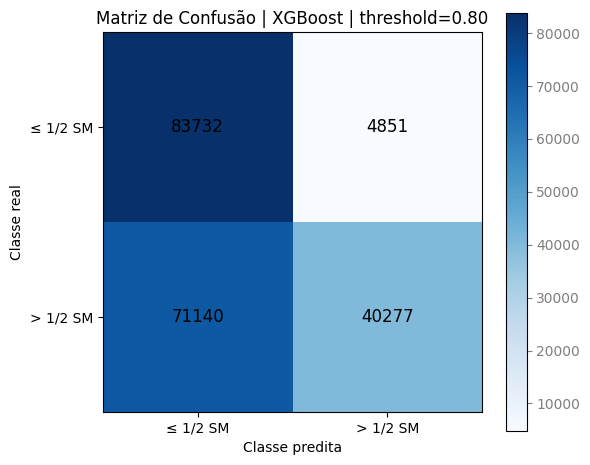

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
THRESHOLD = 0.80  

AZUL = "#1f77b4"
CINZA = "#7f7f7f"

# ------------------------------------------------------------
# 1) PREDIÇÕES NO THRESHOLD DEFINIDO
# ------------------------------------------------------------
# Probabilidade da classe positiva (1 = acima de 1/2 SM)
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# Predição binária com threshold
y_pred = (proba_pos >= THRESHOLD).astype(int)

# ------------------------------------------------------------
# 2) MÉTRICAS NUMÉRICAS
# ------------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"=== Avaliação no threshold = {THRESHOLD:.2f} ===")
print(f"Acurácia            : {acc:.4f}")
print(f"Precisão (classe 1) : {prec:.4f}")
print(f"Revocação (classe 1): {rec:.4f}")
print(f"F1 (classe 1)       : {f1:.4f}")
print(f"Taxa de convocação  : {(y_pred == 1).mean():.4f}")

print("\nMatriz de confusão (valores absolutos):")
print(pd.DataFrame(
    cm,
    index=["Real ≤ 1/2 SM", "Real > 1/2 SM"],
    columns=["Pred ≤ 1/2 SM", "Pred > 1/2 SM"]
))

# ------------------------------------------------------------
# 3) PLOT DA MATRIZ DE CONFUSÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_title(f"Matriz de Confusão | XGBoost | threshold={THRESHOLD:.2f}")
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe real")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["≤ 1/2 SM", "> 1/2 SM"])
ax.set_yticklabels(["≤ 1/2 SM", "> 1/2 SM"])

# Anotações dentro das células
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, int(val), ha="center", va="center", fontsize=12)

# Barra de cor (cinza discreto)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(color=CINZA)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=CINZA)

plt.tight_layout()
plt.show()



ROC-AUC: 0.8256


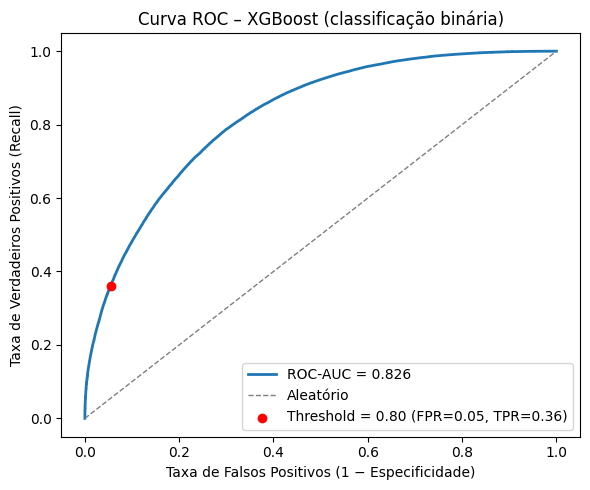

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
VERM = "red"

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA ROC E AUC
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, proba_pos)
roc_auc = roc_auc_score(y_test, proba_pos)
print(f"ROC-AUC: {roc_auc:.4f}")

# Ponto correspondente ao threshold 0.80
idx_thr = np.argmin(np.abs(thresholds - 0.80))
fpr_thr = fpr[idx_thr]
tpr_thr = tpr[idx_thr]

# ------------------------------------------------------------
# 3) PLOT DA CURVA ROC
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color=AZUL, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")

# Linha de referência (classificador aleatório)
ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1, label="Aleatório")

# Ponto do threshold 0.80
ax.scatter(fpr_thr, tpr_thr, color=VERM, zorder=5,
           label=f"Threshold = 0.80 (FPR={fpr_thr:.2f}, TPR={tpr_thr:.2f})")

ax.set_title("Curva ROC – XGBoost (classificação binária)")
ax.set_xlabel("Taxa de Falsos Positivos (1 − Especificidade)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
ax.legend(loc="lower right")
ax.grid(False)
plt.tight_layout()
plt.show()


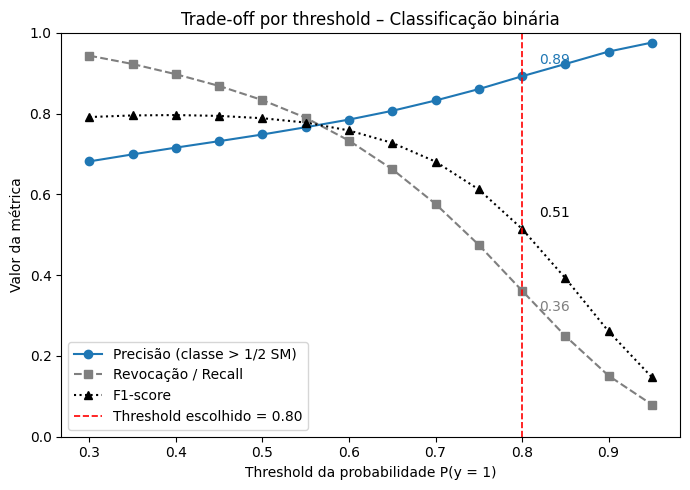

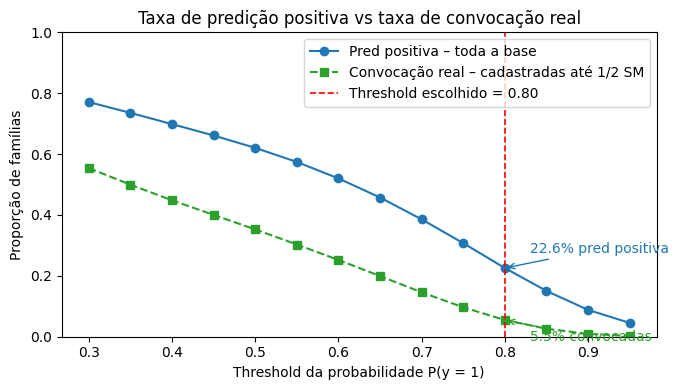

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
PRETO = "#000000"
VERM  = "red"
VERDE = "#2ca02c"
THRESHOLD_FINAL = 0.80
THRESHOLDS = np.arange(0.30, 0.96, 0.05)

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# Máscara: famílias cadastradas como até 1/2 SM (classes 0 e 1)
classe_renda_test = df.loc[X_test.index, "classe_renda"]
mask_ate_meio_sm  = (classe_renda_test != 2).values

# ------------------------------------------------------------
# 2) CÁLCULO DAS MÉTRICAS POR THRESHOLD
# ------------------------------------------------------------
precisoes            = []
revocacoes           = []
f1_scores            = []
taxa_pred_positiva   = []
taxa_convocacao_real = []

for t in THRESHOLDS:
    y_pred = (proba_pos >= t).astype(int)
    precisoes.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    revocacoes.append(recall_score(y_test, y_pred, pos_label=1, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, pos_label=1, zero_division=0))
    taxa_pred_positiva.append((y_pred == 1).mean())
    taxa_convocacao_real.append((y_pred[mask_ate_meio_sm] == 1).mean())

# Índice do threshold operacional
idx_thr = np.argmin(np.abs(THRESHOLDS - THRESHOLD_FINAL))

# ------------------------------------------------------------
# 3) PLOT DO TRADE-OFF (PRECISÃO, RECALL, F1)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(THRESHOLDS, precisoes,  marker="o", color=AZUL,  label="Precisão (classe > 1/2 SM)")
ax.plot(THRESHOLDS, revocacoes, marker="s", color=CINZA, linestyle="--", label="Revocação / Recall")
ax.plot(THRESHOLDS, f1_scores,  marker="^", color=PRETO, linestyle=":",  label="F1-score")

# Linha vertical no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

# Anotações no threshold escolhido
ax.annotate(f"{precisoes[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, precisoes[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, precisoes[idx_thr] + 0.03),
            color=AZUL, fontsize=10)

ax.annotate(f"{revocacoes[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, revocacoes[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, revocacoes[idx_thr] - 0.05),
            color=CINZA, fontsize=10)

ax.annotate(f"{f1_scores[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, f1_scores[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, f1_scores[idx_thr] + 0.03),
            color=PRETO, fontsize=10)

ax.set_title("Trade-off por threshold – Classificação binária")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Valor da métrica")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) PLOT: TAXA DE PREDIÇÃO POSITIVA vs TAXA DE CONVOCAÇÃO REAL
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(THRESHOLDS, taxa_pred_positiva,   marker="o", color=AZUL,  label="Pred positiva – toda a base")
ax.plot(THRESHOLDS, taxa_convocacao_real, marker="s", color=VERDE, linestyle="--", label="Convocação real – cadastradas até 1/2 SM")

# Linha vertical no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

# Anotação: taxa de predição positiva
ax.annotate(
    f"{taxa_pred_positiva[idx_thr]:.1%} pred positiva",
    xy=(THRESHOLD_FINAL, taxa_pred_positiva[idx_thr]),
    xytext=(THRESHOLD_FINAL + 0.03, taxa_pred_positiva[idx_thr] + 0.05),
    arrowprops=dict(arrowstyle="->", color=AZUL),
    color=AZUL, fontsize=10
)

# Anotação: taxa de convocação real
ax.annotate(
    f"{taxa_convocacao_real[idx_thr]:.1%} convocadas",
    xy=(THRESHOLD_FINAL, taxa_convocacao_real[idx_thr]),
    xytext=(THRESHOLD_FINAL + 0.03, taxa_convocacao_real[idx_thr] - 0.07),
    arrowprops=dict(arrowstyle="->", color=VERDE),
    color=VERDE, fontsize=10
)

ax.set_title("Taxa de predição positiva vs taxa de convocação real")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Proporção de famílias")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


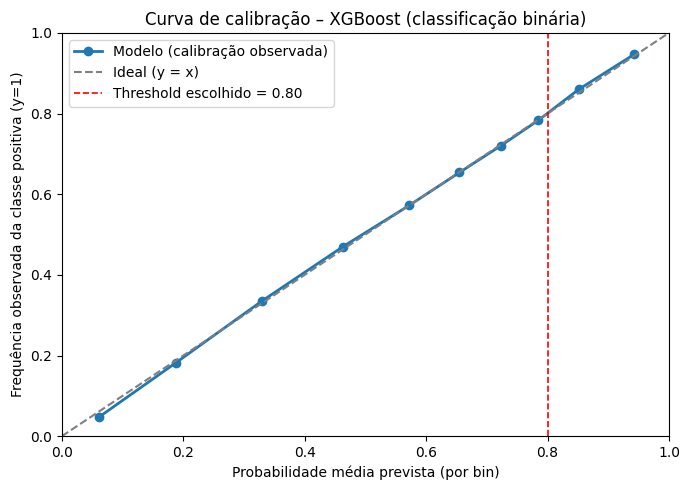

,bin,prob_media_prevista,freq_observada,dif_observada_menos_prevista
0,1,0.0617,0.0480,-0.0137
1,2,0.1881,0.1823,-0.0058
2,3,0.3291,0.3346,0.0055
3,4,0.4629,0.4698,0.0069
4,5,0.5720,0.5720,0.0000
5,6,0.6549,0.6538,-0.0011
6,7,0.7231,0.7202,-0.0029
7,8,0.7849,0.7832,-0.0017
8,9,0.8513,0.8598,0.0085
9,10,0.9431,0.9471,0.0040


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pandas as pd

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
VERM  = "red"
N_BINS = 10
THRESHOLD_FINAL = 0.80

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
frac_pos, mean_pred = calibration_curve(
    y_test,
    proba_pos,
    n_bins=N_BINS,
    strategy="quantile"
)

# ------------------------------------------------------------
# 3) PLOT DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mean_pred, frac_pos, marker="o", color=AZUL, linewidth=2,
        label="Modelo (calibração observada)")

ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1.5,
        label="Ideal (y = x)")

# Marca o threshold operacional no eixo X
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

ax.set_title("Curva de calibração – XGBoost (classificação binária)")
ax.set_xlabel("Probabilidade média prevista (por bin)")
ax.set_ylabel("Frequência observada da classe positiva (y=1)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) TABELA RESUMO DOS BINS
# ------------------------------------------------------------
df_calib = pd.DataFrame({
    "bin":                          np.arange(1, len(mean_pred) + 1),
    "prob_media_prevista":          mean_pred.round(4),
    "freq_observada":               frac_pos.round(4),
    "dif_observada_menos_prevista": (frac_pos - mean_pred).round(4)
})
display(df_calib)


## Análise da importância das variáveis

In [53]:
from sklearn.inspection import permutation_importance
import pandas as pd

def plot_importancia(pipe, X, y, top_n=15, titulo="Modelo"):
    r = permutation_importance(
        pipe, X, y,
        n_repeats=5,
        random_state=42,
        scoring="f1"
    )

    feat_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

    imp = (
        pd.DataFrame({
            "feature": feat_names,
            "importance": r.importances_mean
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    fig, ax = plt.subplots()
    ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=AZUL)
    ax.set_title(f"Importância das variáveis (Top {top_n}) | {titulo}")
    ax.set_xlabel("Queda média no F1")
    plt.show()

    return imp



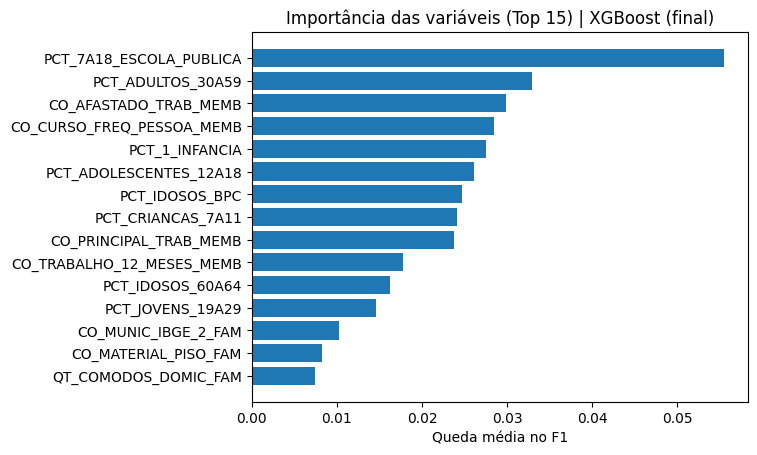

                      feature  importance
44    PCT_7A18_ESCOLA_PUBLICA    0.055512
36          PCT_ADULTOS_30A59    0.032923
28      CO_AFASTADO_TRAB_MEMB    0.029870
27  CO_CURSO_FREQ_PESSOA_MEMB    0.028487
32             PCT_1_INFANCIA    0.027544
34     PCT_ADOLESCENTES_12A18    0.026051
38             PCT_IDOSOS_BPC    0.024707
33          PCT_CRIANCAS_7A11    0.024110
29     CO_PRINCIPAL_TRAB_MEMB    0.023793
30  CO_TRABALHO_12_MESES_MEMB    0.017781
37           PCT_IDOSOS_60A64    0.016282
35           PCT_JOVENS_19A29    0.014642
1         CO_MUNIC_IBGE_2_FAM    0.010299
11       CO_MATERIAL_PISO_FAM    0.008295
8        QT_COMODOS_DOMIC_FAM    0.007452


In [54]:
imp_top = plot_importancia(
    pipe=pipeline_final,
    X=X_test,
    y=y_test,
    top_n=15,
    titulo="XGBoost (final)"
)

print(imp_top)


────────────────────────────────────────────────────────────
  PCT_7A18_ESCOLA_PUBLICA  |  tipo detectado: continua  |  importância: 0.0555
────────────────────────────────────────────────────────────


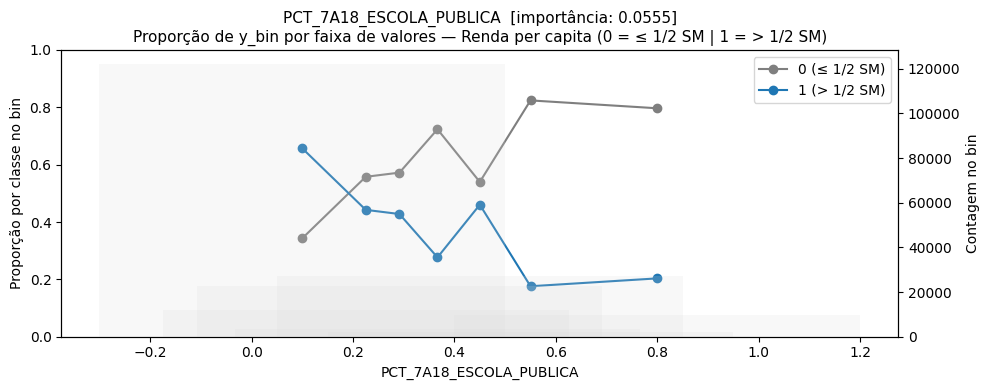

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_7A18_ESCOLA_PUBLICA,,,,
0.000000,39961,79264,119225,66.5
0.500000,14584,12604,27188,46.4
0.333333,12773,9631,22404,43.0
0.250000,6746,5355,12101,44.3
0.666667,5839,1835,7674,23.9
0.400000,2495,965,3460,27.9
0.200000,1591,990,2581,38.4
0.600000,1571,362,1933,18.7
0.750000,1662,161,1823,8.8



────────────────────────────────────────────────────────────
  PCT_ADULTOS_30A59  |  tipo detectado: continua  |  importância: 0.0329
────────────────────────────────────────────────────────────


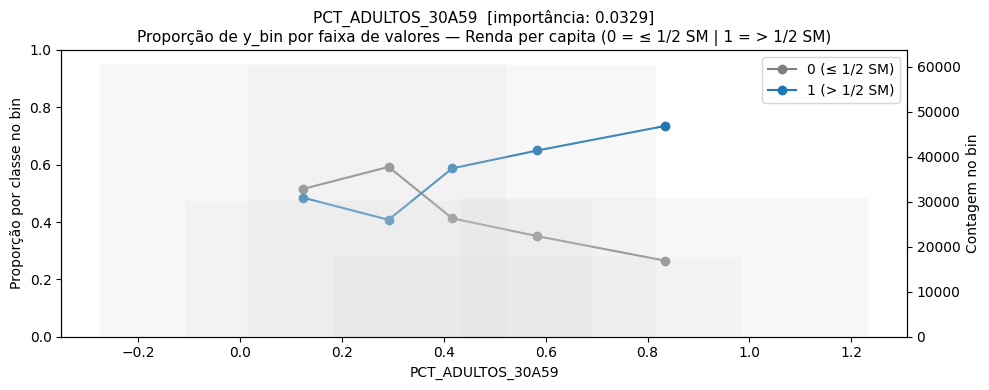

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_ADULTOS_30A59,,,,
0.500000,21480,33288,54768,60.8
0.000000,19086,25517,44603,57.2
1.000000,7977,22186,30163,73.6
0.333333,17561,12257,29818,41.1
0.666667,6107,11362,17469,65.0
0.250000,8412,3224,11636,27.7
0.400000,3474,2202,5676,38.8
0.200000,2678,565,3243,17.4
0.166667,764,95,859,11.1



────────────────────────────────────────────────────────────
  CO_AFASTADO_TRAB_MEMB  |  tipo detectado: categorica  |  importância: 0.0299
────────────────────────────────────────────────────────────


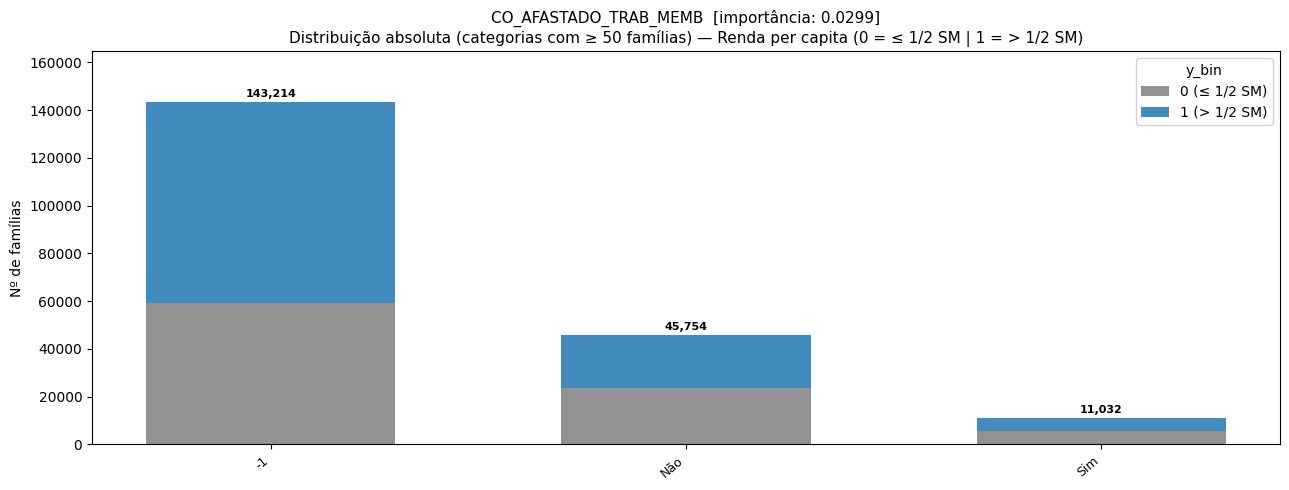

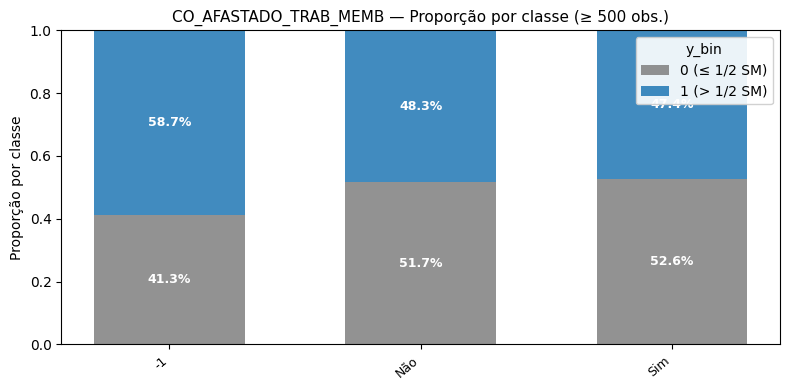

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_AFASTADO_TRAB_MEMB,,,,
-1,59098,84116,143214,58.7
2,23677,22077,45754,48.3
1,5808,5224,11032,47.4



────────────────────────────────────────────────────────────
  CO_CURSO_FREQ_PESSOA_MEMB  |  tipo detectado: categorica  |  importância: 0.0285
────────────────────────────────────────────────────────────


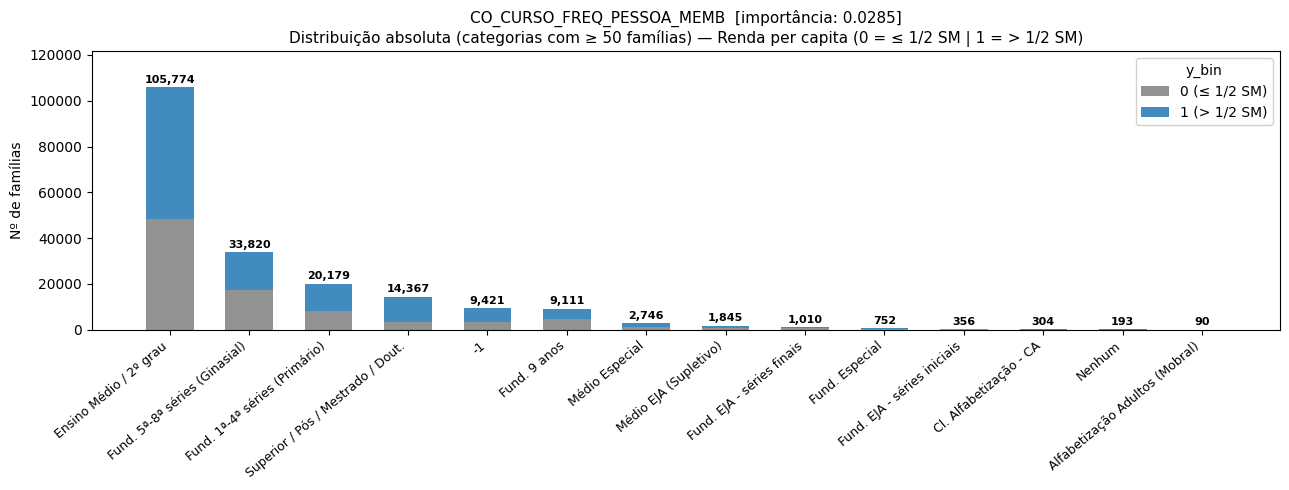

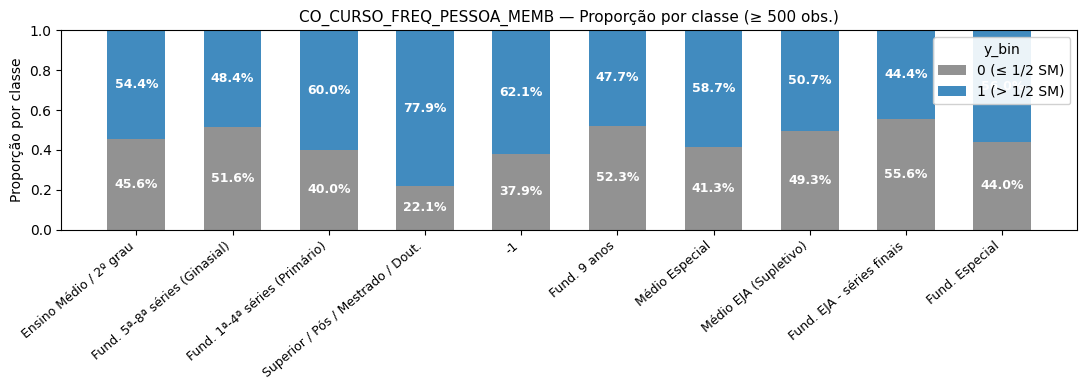

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_CURSO_FREQ_PESSOA_MEMB,,,,
8,48275,57499,105774,54.4
5,17438,16382,33820,48.4
4,8068,12111,20179,60.0
13,3173,11194,14367,77.9
-1,3570,5851,9421,62.1
6,4763,4348,9111,47.7
9,1135,1611,2746,58.7
12,910,935,1845,50.7
11,562,448,1010,44.4



────────────────────────────────────────────────────────────
  PCT_1_INFANCIA  |  tipo detectado: continua  |  importância: 0.0275
────────────────────────────────────────────────────────────


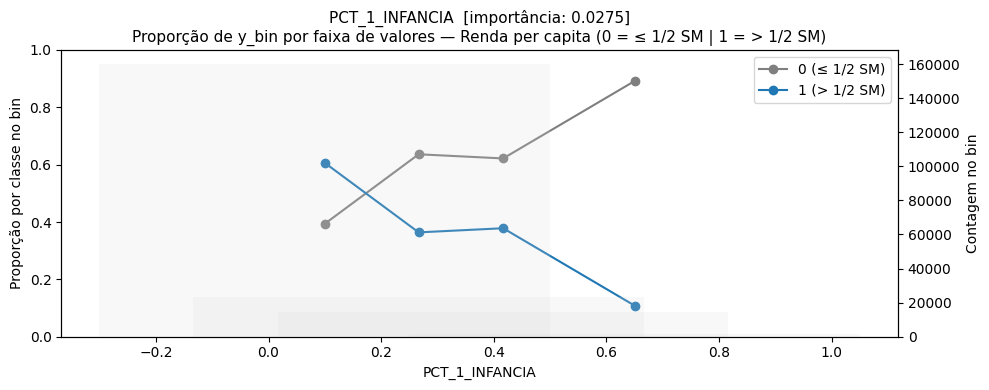

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_1_INFANCIA,,,,
0.000000,59727,96270,155997,61.7
0.333333,8897,5540,14437,38.4
0.500000,8127,5301,13428,39.5
0.250000,5839,2962,8801,33.7
0.200000,2305,769,3074,25.0
0.666667,1382,188,1570,12.0
0.400000,808,167,975,17.1
0.166667,708,143,851,16.8
0.142857,208,35,243,14.4



────────────────────────────────────────────────────────────
  PCT_ADOLESCENTES_12A18  |  tipo detectado: continua  |  importância: 0.0261
────────────────────────────────────────────────────────────


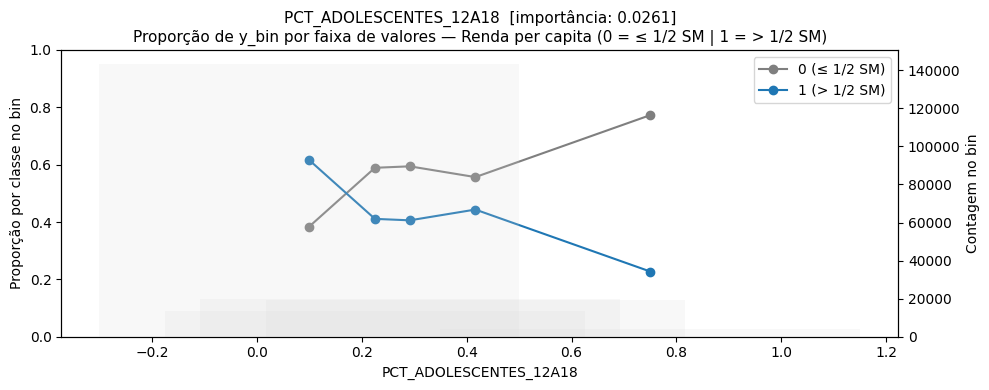

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_ADOLESCENTES_12A18,,,,
0.000000,51586,86882,138468,62.7
0.333333,11447,7957,19404,41.0
0.500000,8633,7926,16559,47.9
0.250000,7857,5496,13353,41.2
0.200000,2644,1339,3983,33.6
0.666667,2288,784,3072,25.5
0.400000,1933,625,2558,24.4
0.166667,613,172,785,21.9
0.600000,439,88,527,16.7



────────────────────────────────────────────────────────────
  PCT_IDOSOS_BPC  |  tipo detectado: categorica  |  importância: 0.0247
────────────────────────────────────────────────────────────


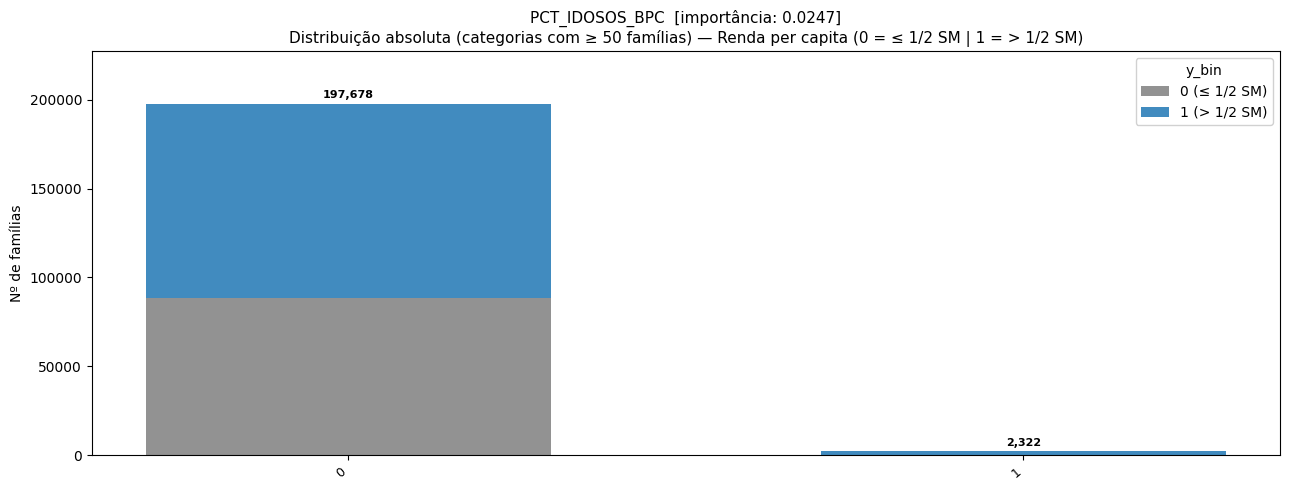

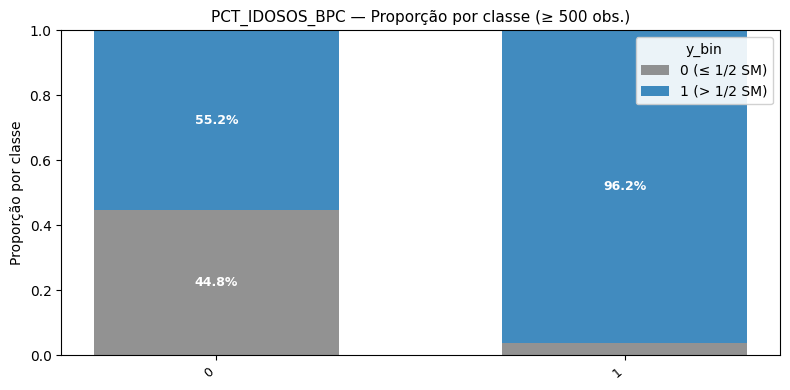

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_IDOSOS_BPC,,,,
0.000000,87332,98806,186138,53.1
0.500000,258,5496,5754,95.5
0.333333,370,2457,2827,86.9
1.000000,88,2234,2322,96.2
0.250000,249,1018,1267,80.3
0.666667,26,869,895,97.1
0.200000,143,319,462,69.0
0.166667,63,68,131,51.9
0.400000,14,99,113,87.6



────────────────────────────────────────────────────────────
  PCT_CRIANCAS_7A11  |  tipo detectado: continua  |  importância: 0.0241
────────────────────────────────────────────────────────────


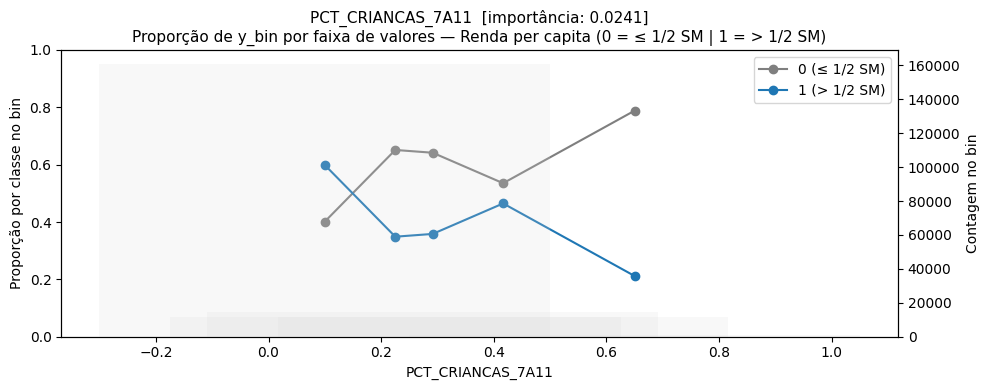

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_CRIANCAS_7A11,,,,
0.000000,60255,95186,155441,61.2
0.333333,9186,5216,14402,36.2
0.250000,7508,4035,11543,35.0
0.500000,5205,5147,10352,49.7
0.200000,3003,1105,4108,26.9
0.400000,926,218,1144,19.1
0.666667,858,252,1110,22.7
0.166667,893,184,1077,17.1
0.142857,245,32,277,11.6



────────────────────────────────────────────────────────────
  CO_PRINCIPAL_TRAB_MEMB  |  tipo detectado: categorica  |  importância: 0.0238
────────────────────────────────────────────────────────────


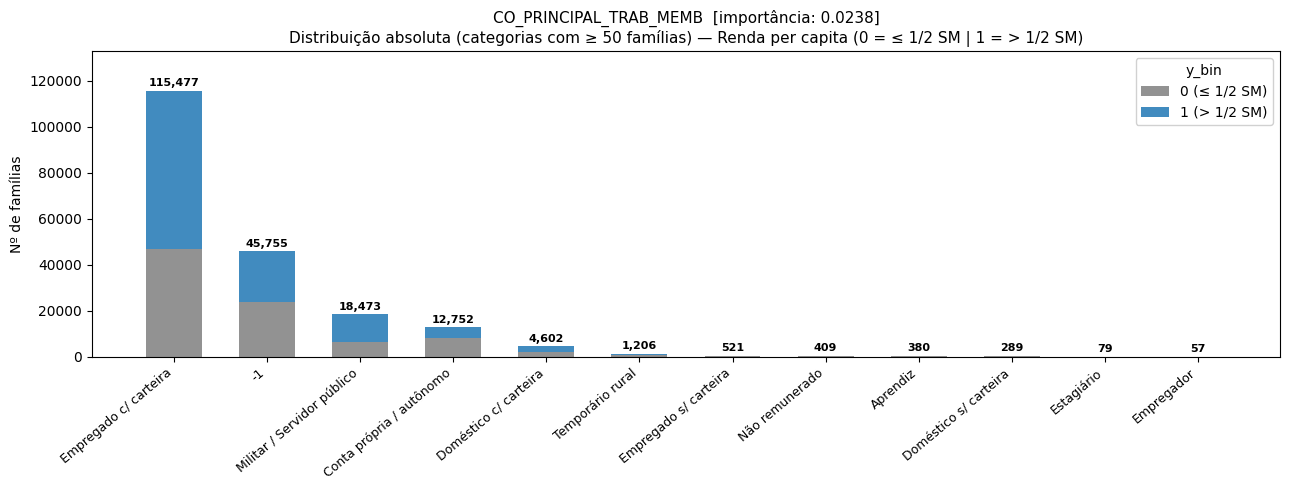

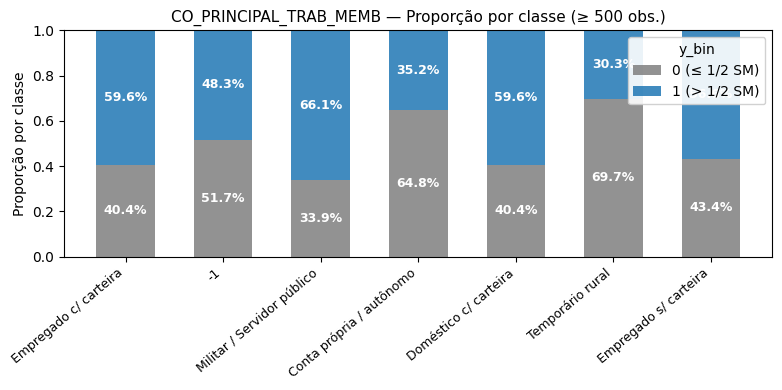

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_PRINCIPAL_TRAB_MEMB,,,,
4,46705,68772,115477,59.6
-1,23677,22078,45755,48.3
8,6263,12210,18473,66.1
1,8263,4489,12752,35.2
6,1861,2741,4602,59.6
2,840,366,1206,30.3
3,226,295,521,56.6
7,284,125,409,30.6
11,237,143,380,37.6



────────────────────────────────────────────────────────────
  CO_TRABALHO_12_MESES_MEMB  |  tipo detectado: categorica  |  importância: 0.0178
────────────────────────────────────────────────────────────


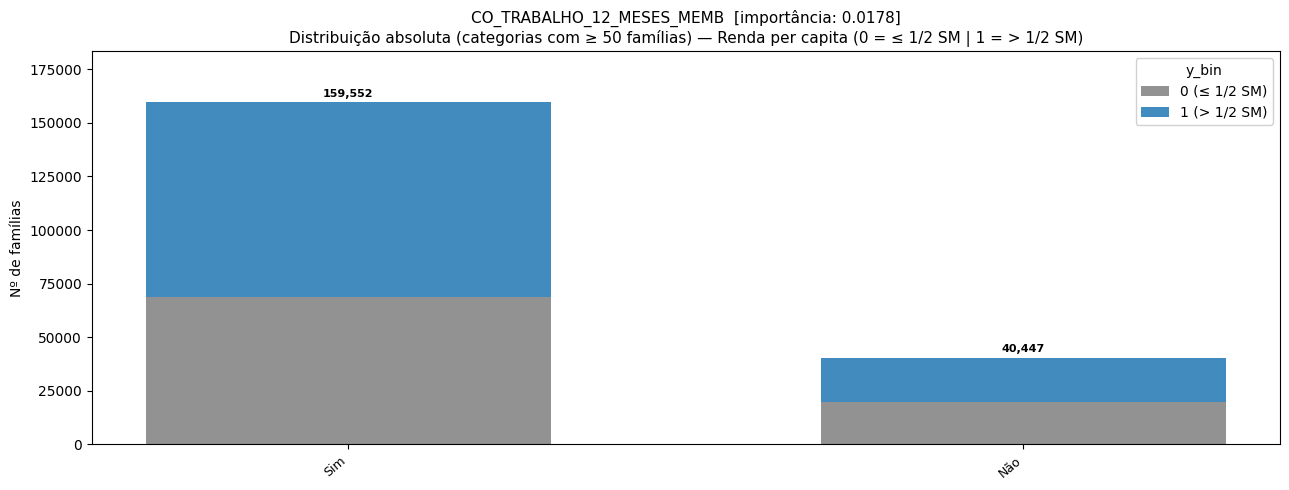

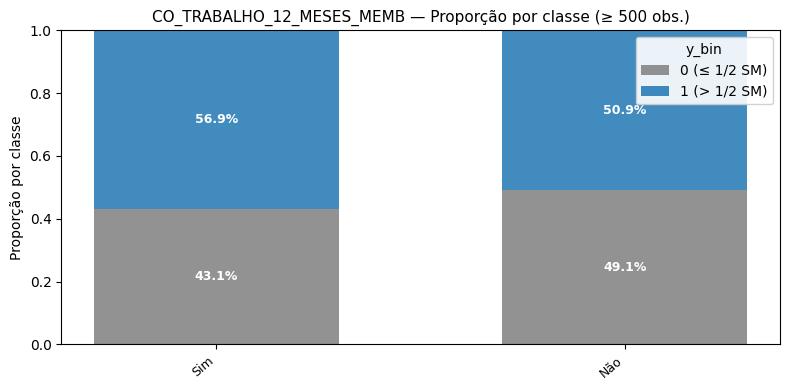

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_TRABALHO_12_MESES_MEMB,,,,
1,68718,90834,159552,56.9
2,19865,20582,40447,50.9
-1,0,1,1,100.0



────────────────────────────────────────────────────────────
  PCT_IDOSOS_60A64  |  tipo detectado: categorica  |  importância: 0.0163
────────────────────────────────────────────────────────────


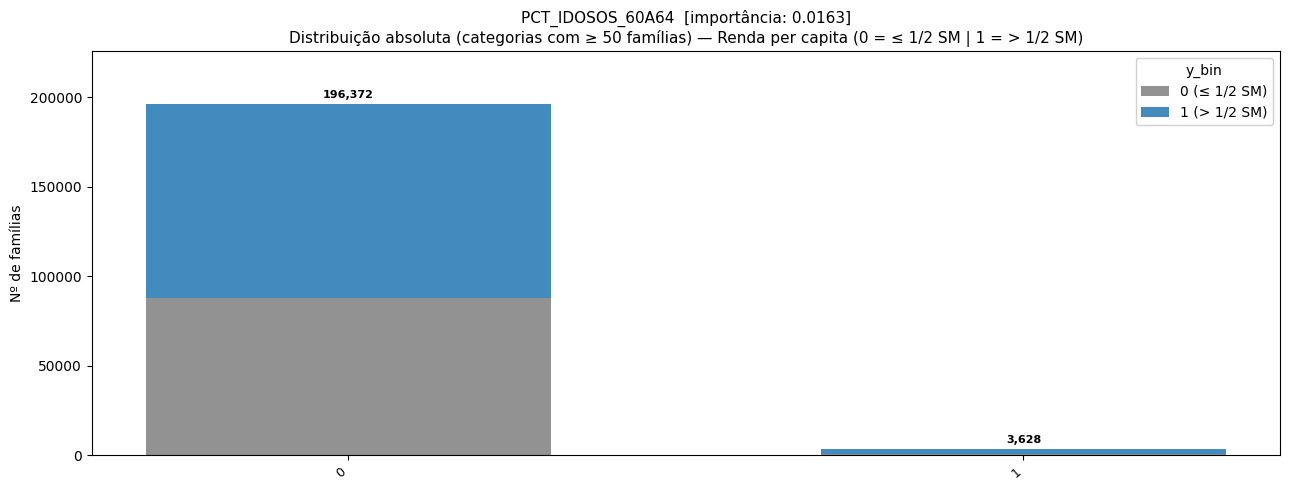

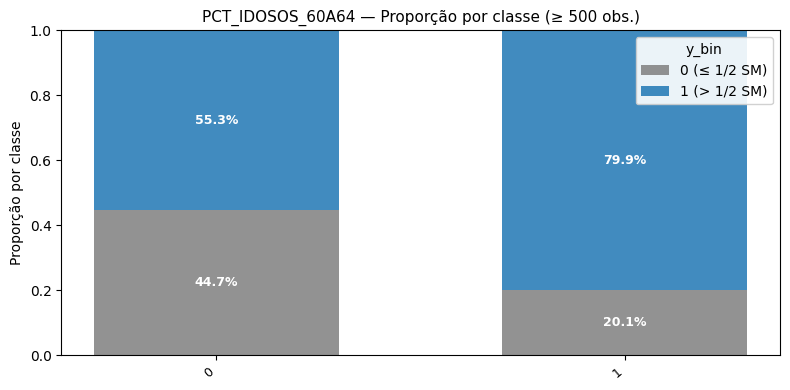

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_IDOSOS_60A64,,,,
0.000000,85200,99363,184563,53.8
0.500000,988,4916,5904,83.3
1.000000,731,2897,3628,79.9
0.333333,761,2492,3253,76.6
0.250000,476,974,1450,67.2
0.666667,94,402,496,81.0
0.200000,182,261,443,58.9
0.166667,90,46,136,33.8
0.400000,20,45,65,69.2



────────────────────────────────────────────────────────────
  PCT_JOVENS_19A29  |  tipo detectado: continua  |  importância: 0.0146
────────────────────────────────────────────────────────────


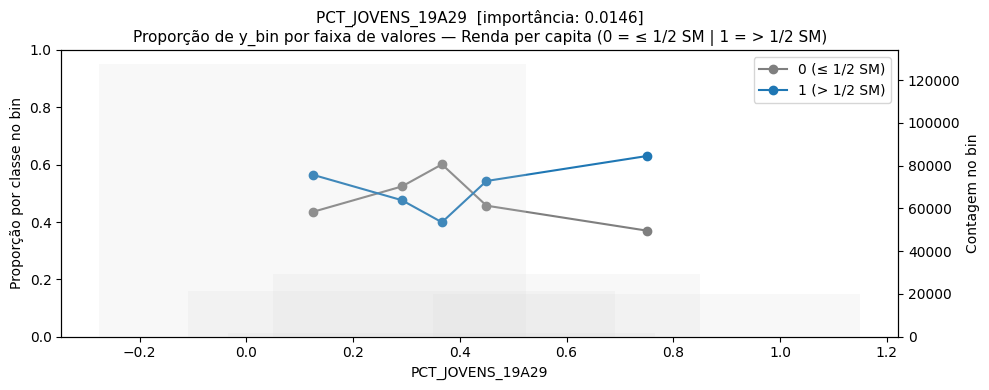

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
PCT_JOVENS_19A29,,,,
0.000000,45973,66308,112281,59.1
0.500000,13320,15888,29208,54.4
0.333333,11148,10207,21355,47.8
1.000000,4139,9286,13425,69.2
0.250000,6306,4604,10910,42.2
0.666667,2719,2725,5444,50.1
0.200000,2363,1036,3399,30.5
0.400000,973,657,1630,40.3
0.166667,657,164,821,20.0



────────────────────────────────────────────────────────────
  CO_MUNIC_IBGE_2_FAM  |  tipo detectado: categorica  |  importância: 0.0103
────────────────────────────────────────────────────────────


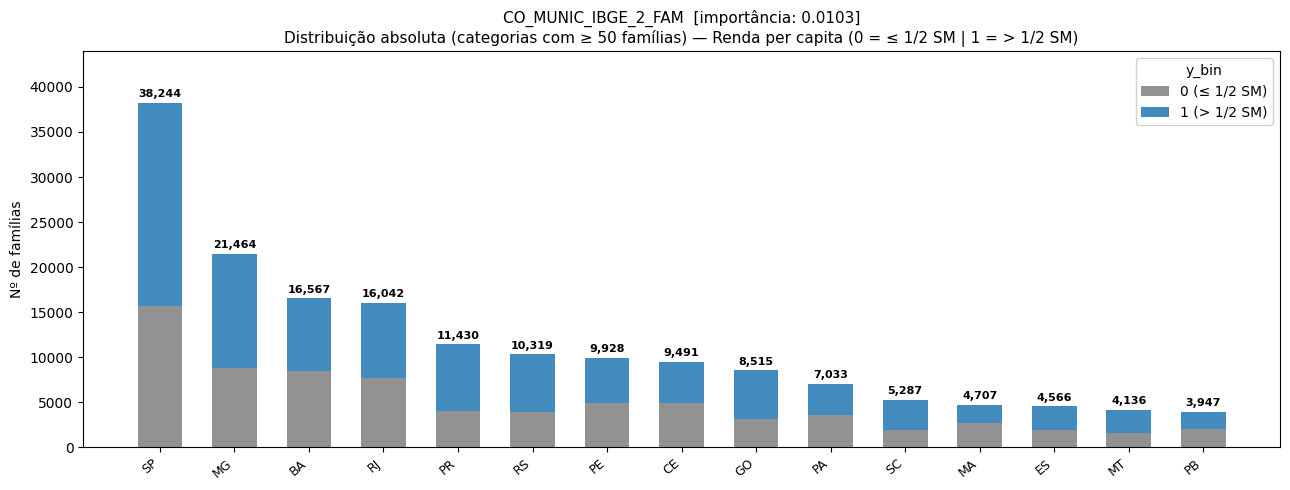

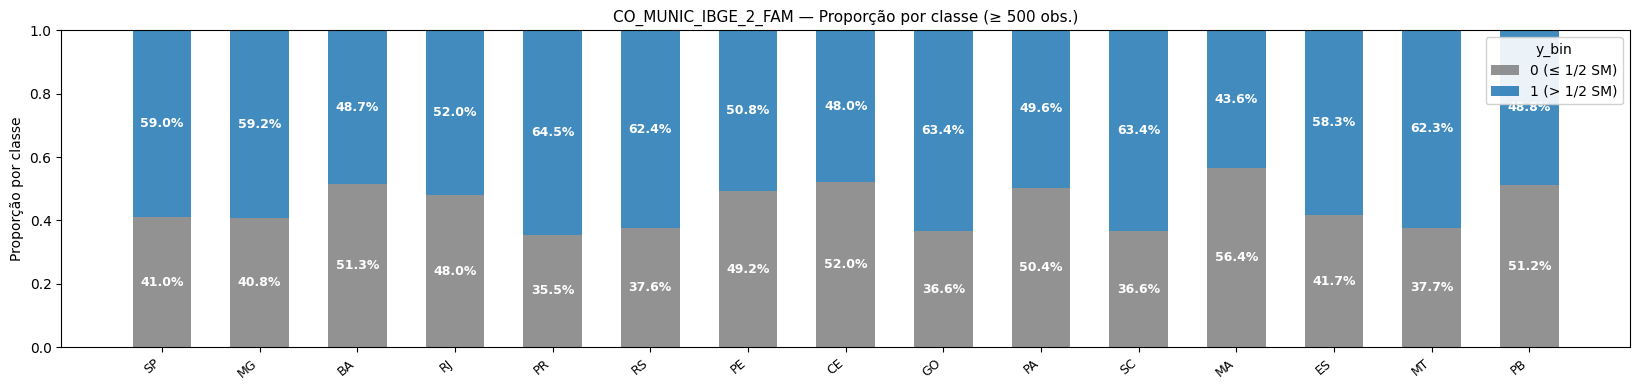

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_MUNIC_IBGE_2_FAM,,,,
35,15672,22572,38244,59.0
31,8750,12714,21464,59.2
29,8506,8061,16567,48.7
33,7701,8341,16042,52.0
41,4054,7376,11430,64.5
43,3875,6444,10319,62.4
26,4885,5043,9928,50.8
23,4937,4554,9491,48.0
52,3116,5399,8515,63.4



────────────────────────────────────────────────────────────
  CO_MATERIAL_PISO_FAM  |  tipo detectado: categorica  |  importância: 0.0083
────────────────────────────────────────────────────────────


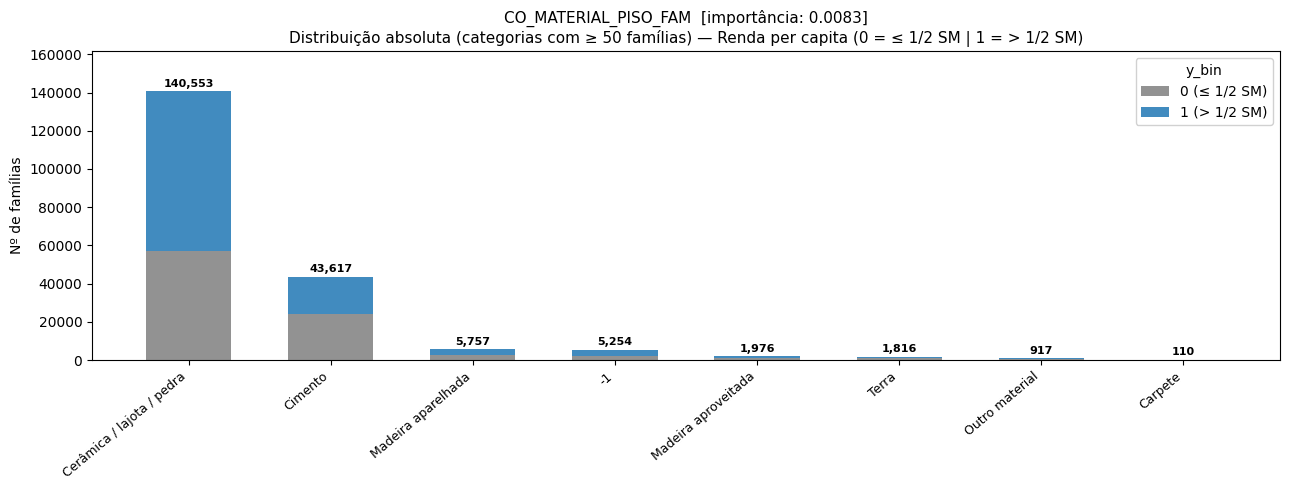

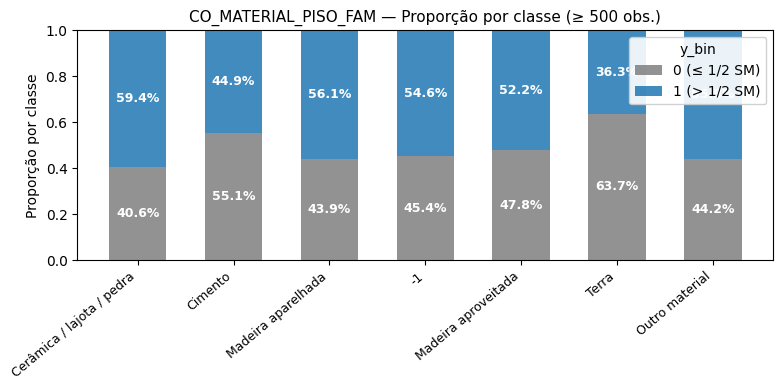

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
CO_MATERIAL_PISO_FAM,,,,
5,57068,83485,140553,59.4
2,24053,19564,43617,44.9
4,2529,3228,5757,56.1
-1,2385,2869,5254,54.6
3,945,1031,1976,52.2
1,1157,659,1816,36.3
7,405,512,917,55.8
6,41,69,110,62.7



────────────────────────────────────────────────────────────
  QT_COMODOS_DOMIC_FAM  |  tipo detectado: continua  |  importância: 0.0075
────────────────────────────────────────────────────────────


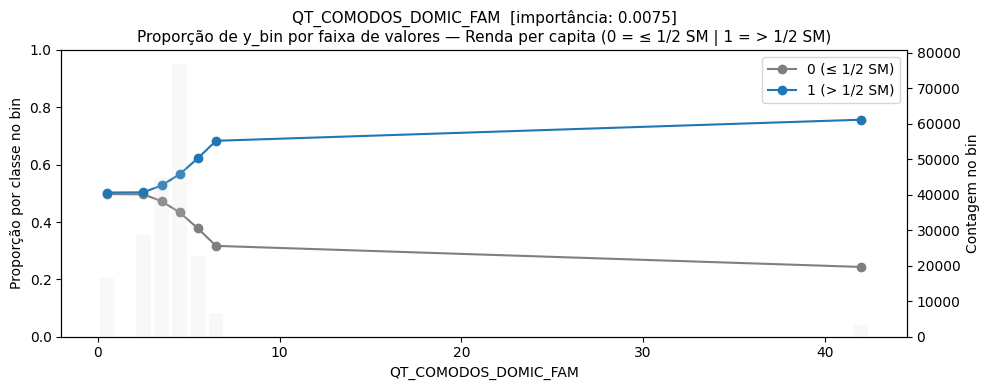

,0 (≤ 1/2 SM),1 (> 1/2 SM),Total,% Cl. 1
QT_COMODOS_DOMIC_FAM,,,,
5,33315,43570,76885,56.7
4,21131,23578,44709,52.7
3,14257,14461,28718,50.4
6,8634,14222,22856,62.2
2,5070,4795,9865,48.6
7,2152,4641,6793,68.3
-1,2385,2869,5254,54.6
8,605,1687,2292,73.6
1,802,680,1482,45.9


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ─────────────────────────────────────────────
# CONFIG GERAL
# ─────────────────────────────────────────────
AZUL        = "#1f77b4"
CINZA       = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"
AZUL_ESCURO = "#0b2d5b"

TARGET      = "y_bin"
CLASSES     = [0, 1]
LEGENDAS    = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
CORES       = {0: CINZA, 1: AZUL}

N_BINS          = 20
TOP_CAT         = 15
MIN_COUNT       = 50
MIN_VOL_PROP    = 500   # volume mínimo para aparecer no gráfico de proporção categórico

TARGET_LABEL = "Renda per capita (0 = ≤ 1/2 SM | 1 = > 1/2 SM)"

# ─────────────────────────────────────────────
# VARIÁVEIS DO imp_top (nome → importância)
# ─────────────────────────────────────────────
variaveis_imp = {
    "PCT_7A18_ESCOLA_PUBLICA"   : 0.055512,
    "PCT_ADULTOS_30A59"         : 0.032923,
    "CO_AFASTADO_TRAB_MEMB"     : 0.029870,
    "CO_CURSO_FREQ_PESSOA_MEMB" : 0.028487,
    "PCT_1_INFANCIA"            : 0.027544,
    "PCT_ADOLESCENTES_12A18"    : 0.026051,
    "PCT_IDOSOS_BPC"            : 0.024707,
    "PCT_CRIANCAS_7A11"         : 0.024110,
    "CO_PRINCIPAL_TRAB_MEMB"    : 0.023793,
    "CO_TRABALHO_12_MESES_MEMB" : 0.017781,
    "PCT_IDOSOS_60A64"          : 0.016282,
    "PCT_JOVENS_19A29"          : 0.014642,
    "CO_MUNIC_IBGE_2_FAM"       : 0.010299,
    "CO_MATERIAL_PISO_FAM"      : 0.008295,
    "QT_COMODOS_DOMIC_FAM"      : 0.007452,
}

# ─────────────────────────────────────────────
# MAPEAMENTOS CATEGÓRICOS CONHECIDOS
# ─────────────────────────────────────────────
MAPAS = {
    "CO_CURSO_FREQ_PESSOA_MEMB": {
        1:  "Creche",
        2:  "Pré-escola (exceto CA)",
        3:  "Cl. Alfabetização - CA",
        4:  "Fund. 1ª-4ª séries (Primário)",
        5:  "Fund. 5ª-8ª séries (Ginasial)",
        6:  "Fund. 9 anos",
        7:  "Fund. Especial",
        8:  "Ensino Médio / 2º grau",
        9:  "Médio Especial",
        10: "Fund. EJA - séries iniciais",
        11: "Fund. EJA - séries finais",
        12: "Médio EJA (Supletivo)",
        13: "Superior / Pós / Mestrado / Dout.",
        14: "Alfabetização Adultos (Mobral)",
        15: "Nenhum",
    },
    "CO_PRINCIPAL_TRAB_MEMB": {
        1:  "Conta própria / autônomo",
        2:  "Temporário rural",
        3:  "Empregado s/ carteira",
        4:  "Empregado c/ carteira",
        5:  "Doméstico s/ carteira",
        6:  "Doméstico c/ carteira",
        7:  "Não remunerado",
        8:  "Militar / Servidor público",
        9:  "Empregador",
        10: "Estagiário",
        11: "Aprendiz",
    },
    "CO_MATERIAL_PISO_FAM": {
        1: "Terra",
        2: "Cimento",
        3: "Madeira aproveitada",
        4: "Madeira aparelhada",
        5: "Cerâmica / lajota / pedra",
        6: "Carpete",
        7: "Outro material",
    },
    "CO_AFASTADO_TRAB_MEMB": {
        1: "Sim",
        2: "Não",
    },
    "CO_TRABALHO_12_MESES_MEMB": {
        1: "Sim",
        2: "Não",
    },
   
    "CO_MUNIC_IBGE_2_FAM": {
        11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA",
        16: "AP", 17: "TO", 21: "MA", 22: "PI", 23: "CE",
        24: "RN", 25: "PB", 26: "PE", 27: "AL", 28: "SE",
        29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
        41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT",
        52: "GO", 53: "DF",
    },
}

# ─────────────────────────────────────────────
# FUNÇÕES AUXILIARES
# ─────────────────────────────────────────────
def detectar_tipo(series, col):
    """Retorna 'binaria', 'continua' ou 'categorica'."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    n_unique = s.nunique()

    if n_unique == 2:
        return "binaria"
    if col in MAPAS or n_unique <= 20:
        return "categorica"
    return "continua"


def aplicar_mapa(series, col):
    """Aplica mapeamento textual se existir, senão usa o valor original como string."""
    mapa = MAPAS.get(col, {})
    def rotular(v):
        if pd.isna(v):
            return "Sem informação"
        k = int(v)
        return mapa.get(k, str(k))
    return series.apply(rotular)


# ─────────────────────────────────────────────
# GRÁFICOS POR TIPO
# ─────────────────────────────────────────────
def plot_continua(df_plot, col, importancia):
    q = min(N_BINS, df_plot[col].nunique())
    df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

    tab  = (df_plot.groupby(["bin", TARGET])
                   .size().unstack(fill_value=0)
                   .reindex(columns=CLASSES, fill_value=0))
    prop    = tab.div(tab.sum(axis=1), axis=0)
    centers = np.array([(b.left + b.right) / 2 for b in prop.index])
    counts  = tab.sum(axis=1).to_numpy()

    fig, ax1 = plt.subplots(figsize=(10, 4))
    for k in CLASSES:
        ax1.plot(centers, prop[k].to_numpy(),
                 marker="o", linewidth=1.5,
                 color=CORES[k], label=LEGENDAS[k])
    ax1.set_ylim(0, 1)
    ax1.set_xlabel(col)
    ax1.set_ylabel("Proporção por classe no bin")
    ax1.set_title(
        f"{col}  [importância: {importancia:.4f}]\n"
        f"Proporção de {TARGET} por faixa de valores — {TARGET_LABEL}",
        fontsize=11
    )
    ax1.legend(loc="upper right")
    ax1.grid(False)

    ax2 = ax1.twinx()
    ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
    ax2.set_ylabel("Contagem no bin")
    plt.tight_layout()
    plt.show()


def plot_categorica(df_plot, col, importancia):
    df_plot["rotulo"] = aplicar_mapa(
        pd.to_numeric(df_plot[col], errors="coerce"), col
    )

    top = df_plot["rotulo"].value_counts().head(TOP_CAT).index
    df_plot = df_plot[df_plot["rotulo"].isin(top)].copy()

    tab    = (df_plot.groupby(["rotulo", TARGET])
                     .size().unstack(fill_value=0)
                     .reindex(columns=CLASSES, fill_value=0))
    prop   = tab.div(tab.sum(axis=1), axis=0)
    counts = tab.sum(axis=1)

    # ── Filtro de volume mínimo para o gráfico de barras ─────
    mask_min = counts >= MIN_COUNT   # MIN_COUNT = 50 já definido no config
    tab_vol    = tab.loc[mask_min]
    counts_vol = counts.loc[mask_min]
    prop_vol   = prop.loc[mask_min]

    # Ordenação por volume decrescente
    ordem = counts_vol.sort_values(ascending=False).index
    prop_vol   = prop_vol.loc[ordem]
    tab_vol    = tab_vol.loc[ordem]
    counts_vol = counts_vol.loc[ordem]
    x_all      = np.arange(len(prop_vol.index))

    # — Plot 1: volume absoluto (apenas categorias com >= MIN_COUNT) —
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x_all, tab_vol[0].to_numpy(), width=0.6,
           color=CINZA, label=LEGENDAS[0], alpha=0.85)
    ax.bar(x_all, tab_vol[1].to_numpy(), width=0.6,
           color=AZUL,  label=LEGENDAS[1], alpha=0.85,
           bottom=tab_vol[0].to_numpy())
    for i, total in enumerate(counts_vol):
        ax.text(i, total + counts_vol.max() * 0.01,
                f"{total:,.0f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
    ax.set_ylim(0, counts_vol.max() * 1.15)
    ax.set_xticks(x_all)
    ax.set_xticklabels(prop_vol.index, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Nº de famílias")
    ax.set_title(
        f"{col}  [importância: {importancia:.4f}]\n"
        f"Distribuição absoluta (categorias com ≥ {MIN_COUNT} famílias) — {TARGET_LABEL}",
        fontsize=11
    )
    ax.legend(title=TARGET, loc="upper right",
              bbox_to_anchor=(1, 1), framealpha=0.9)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    # — Plot 2: proporção (apenas categorias com >= MIN_VOL_PROP) —
    mask   = counts >= MIN_VOL_PROP
    prop_f = prop.loc[mask]
    if prop_f.empty:
        print(f"  ⚠ Nenhuma categoria de '{col}' com ≥ {MIN_VOL_PROP} obs.")
        return

    # Reordena por volume para manter consistência com plot 1
    ordem_f = counts.loc[mask].sort_values(ascending=False).index
    prop_f  = prop_f.loc[ordem_f]
    x_f     = np.arange(len(prop_f.index))
    bottom  = np.zeros(len(prop_f.index))

    fig, ax = plt.subplots(figsize=(max(8, len(prop_f) * 1.1), 4))
    for k in CLASSES:
        vals = prop_f[k].to_numpy()
        ax.bar(x_f, vals, bottom=bottom, width=0.6,
               label=LEGENDAS[k], color=CORES[k], alpha=0.85)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.04:
                ax.text(i, b + v / 2, f"{v:.1%}",
                        ha="center", va="center",
                        fontsize=9, color="white", fontweight="bold")
        bottom += vals
    ax.set_xticks(x_f)
    ax.set_xticklabels(prop_f.index, rotation=40, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proporção por classe")
    ax.set_title(
        f"{col} — Proporção por classe (≥ {MIN_VOL_PROP:,} obs.)",
        fontsize=11
    )
    ax.legend(title=TARGET, loc="upper right",
              bbox_to_anchor=(1, 1), framealpha=0.9)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_binaria(df_plot, col, importancia):
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
    df_plot = df_plot.dropna(subset=[col])
    df_plot["rotulo"] = df_plot[col].astype(int).astype(str)

    tab    = (df_plot.groupby(["rotulo", TARGET])
                     .size().unstack(fill_value=0)
                     .reindex(columns=CLASSES, fill_value=0))
    prop   = tab.div(tab.sum(axis=1), axis=0)
    counts = tab.sum(axis=1)
    x_all  = np.arange(len(prop.index))

    fig, ax = plt.subplots(figsize=(5, 4))
    bottom = np.zeros(len(prop.index))
    for k in CLASSES:
        vals = prop[k].to_numpy()
        ax.bar(x_all, vals, bottom=bottom, width=0.5,
               label=LEGENDAS[k], color=CORES[k], alpha=0.85)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.04:
                ax.text(i, b + v / 2, f"{v:.1%}",
                        ha="center", va="center",
                        fontsize=10, color="white", fontweight="bold")
        bottom += vals
    for i, total in enumerate(counts):
        ax.text(i, 1.02, f"n={total:,.0f}", ha="center",
                fontsize=8, color="gray")
    ax.set_xticks(x_all)
    ax.set_xticklabels(prop.index, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Proporção por classe")
    ax.set_xlabel(col)
    ax.set_title(
        f"{col}  [importância: {importancia:.4f}]\n"
        f"Proporção de {TARGET} — {TARGET_LABEL}",
        fontsize=11
    )
    ax.legend(title=TARGET)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# LOOP PRINCIPAL — roda para todas as variáveis
# ─────────────────────────────────────────────
for col, imp in variaveis_imp.items():
    if col not in X_test.columns:
        print(f"⚠ Coluna '{col}' não encontrada em X_test — pulando.")
        continue

    df_plot = X_test[[col]].copy()
    df_plot[TARGET] = y_test.values

    tipo = detectar_tipo(df_plot[col], col)
    print(f"\n{'─'*60}")
    print(f"  {col}  |  tipo detectado: {tipo}  |  importância: {imp:.4f}")
    print(f"{'─'*60}")

    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
    df_plot = df_plot.dropna(subset=[col, TARGET])

    if tipo == "continua":
        plot_continua(df_plot.copy(), col, imp)
    elif tipo == "categorica":
        plot_categorica(df_plot.copy(), col, imp)
    else:
        plot_binaria(df_plot.copy(), col, imp)

    # Tabela resumo por variável
    resumo = (df_plot.groupby([col, TARGET]).size()
              .unstack(fill_value=0)
              .reindex(columns=CLASSES, fill_value=0))
    resumo.columns = [LEGENDAS[c] for c in CLASSES]
    resumo["Total"]    = resumo.sum(axis=1)
    resumo["% Cl. 1"]  = (resumo[LEGENDAS[1]] / resumo["Total"] * 100).round(1)
    resumo = resumo.sort_values("Total", ascending=False).head(TOP_CAT)
    with pd.option_context("display.max_colwidth", 60):
        display(resumo)

In [56]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
COL_ESCOLA   = "PCT_7A18_ESCOLA_PUBLICA"
COLS_CRIANCA = ["PCT_1_INFANCIA", "PCT_CRIANCAS_7A11", "PCT_ADOLESCENTES_12A18"]

# ─────────────────────────────────────────────
# PREP  (usa df_diag — NÃO sobrescreve o df original)
# ─────────────────────────────────────────────
df_diag = X_test.copy()
df_diag["y_bin"] = y_test.values

# Converte para numérico
df_diag[COL_ESCOLA] = pd.to_numeric(df_diag[COL_ESCOLA], errors="coerce")
for c in COLS_CRIANCA:
    df_diag[c] = pd.to_numeric(df_diag[c], errors="coerce")

total = len(df_diag)

# ─────────────────────────────────────────────
# FLAGS
# ─────────────────────────────────────────────

# Tem alguma criança na composição familiar (qualquer faixa etária)
df_diag["tem_crianca"] = (
    (df_diag["PCT_1_INFANCIA"]         > 0) |
    (df_diag["PCT_CRIANCAS_7A11"]      > 0) |
    (df_diag["PCT_ADOLESCENTES_12A18"] > 0)
).fillna(False)

# Tem marcação na variável de escola
df_diag["tem_escola_marcada"] = df_diag[COL_ESCOLA].notna() & (df_diag[COL_ESCOLA] > 0)

# ─────────────────────────────────────────────
# GRUPOS ANALÍTICOS
# ─────────────────────────────────────────────
# G1 — Tem criança E tem escola marcada       → esperado / ok
# G2 — Tem criança E NÃO tem escola marcada   → ⚠ inconsistência de interesse
# G3 — Sem criança E tem escola marcada       → incomum, vale checar
# G4 — Sem criança E sem escola marcada       → esperado / ok

conditions = [
    ( df_diag["tem_crianca"] &  df_diag["tem_escola_marcada"]),
    ( df_diag["tem_crianca"] & ~df_diag["tem_escola_marcada"]),
    (~df_diag["tem_crianca"] &  df_diag["tem_escola_marcada"]),
    (~df_diag["tem_crianca"] & ~df_diag["tem_escola_marcada"]),
]
labels = [
    "G1 — Tem criança  | Com escola marcada",
    "G2 — Tem criança  | SEM escola marcada  ⚠",
    "G3 — Sem criança  | Com escola marcada",
    "G4 — Sem criança  | Sem escola marcada",
]
df_diag["grupo"] = np.select(conditions, labels, default="?")

# ─────────────────────────────────────────────
# RESUMO GERAL
# ─────────────────────────────────────────────
print("=" * 70)
print("DIAGNÓSTICO — Crianças na composição × Escola marcada")
print("=" * 70)
print(f"\nTotal de famílias: {total:,}\n")

resumo = (df_diag.groupby("grupo")
                 .size()
                 .reset_index(name="N"))
resumo["%"] = (resumo["N"] / total * 100).round(1)
resumo = resumo.sort_values("grupo")

print(f"{'Grupo':<45} {'N':>10} {'%':>7}")
print("-" * 65)
for _, row in resumo.iterrows():
    print(f"{row['grupo']:<45} {row['N']:>10,} {row['%']:>6.1f}%")

# ─────────────────────────────────────────────
# FOCO: G2 — Tem criança mas sem escola marcada
# ─────────────────────────────────────────────
g2 = df_diag[df_diag["grupo"] == "G2 — Tem criança  | SEM escola marcada  ⚠"].copy()

print(f"\n{'=' * 70}")
print(f"DETALHAMENTO — G2: famílias COM criança e SEM escola marcada (n={len(g2):,})")
print(f"{'=' * 70}")

# Qual faixa etária está presente nessas famílias?
print("\nPresença por faixa etária (% do G2):")
print("-" * 45)
for c in COLS_CRIANCA:
    n = (g2[c] > 0).sum()
    print(f"  {c:<35} {n:>8,}  ({n/len(g2)*100:.1f}%)")

# Sobreposições
apenas_infancia  = ((g2["PCT_1_INFANCIA"] > 0) &
                    (g2["PCT_CRIANCAS_7A11"] == 0) &
                    (g2["PCT_ADOLESCENTES_12A18"] == 0)).sum()

apenas_7a11      = ((g2["PCT_1_INFANCIA"] == 0) &
                    (g2["PCT_CRIANCAS_7A11"] > 0) &
                    (g2["PCT_ADOLESCENTES_12A18"] == 0)).sum()

apenas_adol      = ((g2["PCT_1_INFANCIA"] == 0) &
                    (g2["PCT_CRIANCAS_7A11"] == 0) &
                    (g2["PCT_ADOLESCENTES_12A18"] > 0)).sum()

mais_de_uma      = len(g2) - apenas_infancia - apenas_7a11 - apenas_adol

print(f"\nComposição exclusiva no G2:")
print("-" * 45)
print(f"  Só 1ª infância (0-6 anos)          {apenas_infancia:>8,}  ({apenas_infancia/len(g2)*100:.1f}%)")
print(f"  Só crianças 7-11 anos              {apenas_7a11:>8,}  ({apenas_7a11/len(g2)*100:.1f}%)")
print(f"  Só adolescentes 12-18 anos         {apenas_adol:>8,}  ({apenas_adol/len(g2)*100:.1f}%)")
print(f"  Mais de uma faixa etária           {mais_de_uma:>8,}  ({mais_de_uma/len(g2)*100:.1f}%)")

# Cruzamento com target
print(f"\nCruzamento G2 × y_bin:")
print("-" * 45)
cruz = (g2.groupby("y_bin").size().reset_index(name="N"))
cruz["%"] = (cruz["N"] / len(g2) * 100).round(1)
cruz["y_bin"] = cruz["y_bin"].map({0: "0 — ≤ 1/2 SM", 1: "1 — > 1/2 SM"})
for _, row in cruz.iterrows():
    print(f"  {row['y_bin']:<20} {row['N']:>8,}  ({row['%']}%)")

# Valor de PCT_7A18_ESCOLA_PUBLICA no G2 (NaN vs zero)
print(f"\nNatureza da 'ausência de marcação' em {COL_ESCOLA} no G2:")
print("-" * 45)
n_nan  = g2[COL_ESCOLA].isna().sum()
n_zero = (g2[COL_ESCOLA] == 0).sum()
print(f"  NaN  (campo vazio / não respondido) {n_nan:>7,}  ({n_nan/len(g2)*100:.1f}%)")
print(f"  Zero (marcado como 0%)              {n_zero:>7,}  ({n_zero/len(g2)*100:.1f}%)")

DIAGNÓSTICO — Crianças na composição × Escola marcada

Total de famílias: 200,000

Grupo                                                  N       %
-----------------------------------------------------------------
G1 — Tem criança  | Com escola marcada            80,775   40.4%
G2 — Tem criança  | SEM escola marcada  ⚠         31,778   15.9%
G4 — Sem criança  | Sem escola marcada            87,447   43.7%

DETALHAMENTO — G2: famílias COM criança e SEM escola marcada (n=31,778)

Presença por faixa etária (% do G2):
---------------------------------------------
  PCT_1_INFANCIA                        25,087  (78.9%)
  PCT_CRIANCAS_7A11                      4,296  (13.5%)
  PCT_ADOLESCENTES_12A18                 4,424  (13.9%)

Composição exclusiva no G2:
---------------------------------------------
  Só 1ª infância (0-6 anos)            23,527  (74.0%)
  Só crianças 7-11 anos                 3,051  (9.6%)
  Só adolescentes 12-18 anos            3,231  (10.2%)
  Mais de uma faixa etária 

In [57]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import numpy as np
import pandas as pd
import collections
from scipy import sparse
from sklearn.pipeline import Pipeline
from IPython.display import display

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
SEED        = 42
N_SHAP      = 20000   # amostra p/ acelerar o SHAP (None = usa todo o X_test)
TOP_MOSTRAR = None    # None = todas as variáveis; ou um inteiro p/ top-N

# importâncias do imp_top (só para comparação lado a lado; opcional)
variaveis_imp = {
    "PCT_7A18_ESCOLA_PUBLICA": 0.055512, "PCT_ADULTOS_30A59": 0.032923,
    "CO_AFASTADO_TRAB_MEMB": 0.029870, "CO_CURSO_FREQ_PESSOA_MEMB": 0.028487,
    "PCT_1_INFANCIA": 0.027544, "PCT_ADOLESCENTES_12A18": 0.026051,
    "PCT_IDOSOS_BPC": 0.024707, "PCT_CRIANCAS_7A11": 0.024110,
    "CO_PRINCIPAL_TRAB_MEMB": 0.023793, "CO_TRABALHO_12_MESES_MEMB": 0.017781,
    "PCT_IDOSOS_60A64": 0.016282, "PCT_JOVENS_19A29": 0.014642,
    "CO_MUNIC_IBGE_2_FAM": 0.010299, "CO_MATERIAL_PISO_FAM": 0.008295,
    "QT_COMODOS_DOMIC_FAM": 0.007452,
}

# ─────────────────────────────────────────────
# 1) Localizar preprocessor e modelo dentro do pipeline
# ─────────────────────────────────────────────
def extrair_pre_modelo(pipe):
    pre = None
    if isinstance(pipe, Pipeline):
        for _, step in pipe.named_steps.items():
            if hasattr(step, "transform") and hasattr(step, "get_feature_names_out"):
                pre = step
        modelo = list(pipe.named_steps.values())[-1]
    else:                                  # wrapper custom: tenta atributos comuns
        modelo = getattr(pipe, "model", getattr(pipe, "estimator", pipe))
        if isinstance(modelo, Pipeline):
            return extrair_pre_modelo(modelo)
    return pre, modelo

pre, modelo = extrair_pre_modelo(pipeline_final)
if pre is None:
    raise RuntimeError("Não encontrei o preprocessor no pipeline_final.")

# ─────────────────────────────────────────────
# 2) Amostra do X_test e transformação
# ─────────────────────────────────────────────
if N_SHAP is not None and len(X_test) > N_SHAP:
    X_amostra = X_test.sample(N_SHAP, random_state=SEED)
else:
    X_amostra = X_test

Xt = pre.transform(X_amostra)
if sparse.issparse(Xt):
    Xt = Xt.toarray()
feat_names = list(pre.get_feature_names_out())

# ─────────────────────────────────────────────
# 3) SHAP — desembrulhando o wrapper XGBoostComThreshold
# ─────────────────────────────────────────────
try:
    import shap
except ImportError:
    raise ImportError("Instale o SHAP:  pip install shap")

import xgboost as xgb

def localizar_xgb(obj, _visto=None):
    """Procura recursivamente um XGBClassifier/Booster dentro de um wrapper."""
    if _visto is None:
        _visto = set()
    if id(obj) in _visto:
        return None
    _visto.add(id(obj))

    # caso direto: já é um modelo XGBoost (tem get_booster)
    if isinstance(obj, (xgb.XGBClassifier, xgb.XGBRegressor, xgb.Booster)):
        return obj
    if hasattr(obj, "get_booster"):
        return obj

    # procura nos atributos do objeto (.model, .estimator, .clf, etc.)
    if hasattr(obj, "__dict__"):
        for v in vars(obj).values():
            achado = localizar_xgb(v, _visto)
            if achado is not None:
                return achado

    # procura dentro de pipelines aninhados
    if isinstance(obj, Pipeline):
        for _, step in obj.named_steps.items():
            achado = localizar_xgb(step, _visto)
            if achado is not None:
                return achado
    return None

xgb_model = localizar_xgb(modelo)
if xgb_model is None:
    # diagnóstico: mostra os atributos do wrapper para você ver onde está o modelo
    attrs = list(vars(modelo).keys()) if hasattr(modelo, "__dict__") else []
    raise RuntimeError(
        "Não encontrei o XGBClassifier dentro do wrapper "
        f"{type(modelo).__name__}. Atributos disponíveis: {attrs}"
    )

explainer = shap.TreeExplainer(xgb_model)
sv = explainer.shap_values(Xt)
if isinstance(sv, list):                   # multiclasse antigo -> pega classe 1
    sv = sv[1] if len(sv) > 1 else sv[0]
sv = np.asarray(sv)

# ─────────────────────────────────────────────
# 4) Mapear feature transformada -> variável original
# ─────────────────────────────────────────────
cols_orig = list(X_test.columns)
def variavel_original(nome):
    base = nome.split("__", 1)[1] if "__" in nome else nome
    cand = [c for c in cols_orig if base == c or base.startswith(c + "_")]
    if cand:
        return max(cand, key=len)
    cand = [c for c in cols_orig if c in base]
    return max(cand, key=len) if cand else base

grupos = collections.defaultdict(list)
for j, fn in enumerate(feat_names):
    grupos[variavel_original(fn)].append(j)

# ─────────────────────────────────────────────
# NOMES AMIGÁVEIS (código → linguagem comum)
# ─────────────────────────────────────────────
NOMES = {
    # ── Domicílio / infraestrutura ────────────────────────────────
    "CO_ABASTE_AGUA_DOMIC_FAM"     : "Forma de abastecimento de água",
    "CO_AGUA_CANALIZADA_FAM"       : "Domicílio tem água encanada",
    "CO_BANHEIRO_DOMIC_FAM"        : "Domicílio tem banheiro",
    "CO_ESCOA_SANITARIO_DOMIC_FAM" : "Forma de escoamento sanitário",
    "CO_ESPECIE_DOMIC_FAM"         : "Espécie do domicílio (particular / coletivo)",
    "CO_ILUMINACAO_DOMIC_FAM"      : "Tipo de iluminação do domicílio",
    "CO_LOCAL_DOMIC_FAM"           : "Domicílio rural ou urbano",
    "CO_MATERIAL_DOMIC_FAM"        : "Material das paredes externas",
    "CO_MATERIAL_PISO_FAM"         : "Material do piso do domicílio",
    "QT_COMODOS_DOMIC_FAM"         : "Nº de cômodos no domicílio",
    "QT_COMODOS_DORMITORIO_FAM"    : "Nº de cômodos usados como dormitório",
    "QT_FAMILIAS_DOMIC_FAM"        : "Nº de famílias no domicílio",
    "QT_PESSOAS_DOMIC_FAM"         : "Nº de pessoas no domicílio",

    # ── Localização ───────────────────────────────────────────────
    "CO_MUNIC_IBGE_2_FAM"          : "Estado (UF)",
    "CO_MUNIC_IBGE_5_FAM"          : "Código do município (2ª parte IBGE)",

    # ── Responsável familiar: trabalho ────────────────────────────
    "CO_AFASTADO_TRAB_MEMB"        : "Responsável afastado do trabalho (semana passada)",
    "CO_AGRICULTURA_TRAB_MEMB"     : "Trabalho é atividade extrativista",
    "CO_PRINCIPAL_TRAB_MEMB"       : "Tipo do trabalho principal",
    "CO_TRABALHO_12_MESES_MEMB"    : "Trabalhou (remunerado) nos últimos 12 meses",
    "CO_TRABALHOU_SEMANA_MEMB"     : "Trabalhou na semana passada",

    # ── Responsável familiar: educação / perfil ───────────────────
    "CO_CURSO_FREQ_PESSOA_MEMB"    : "Curso mais elevado que o responsável frequentou",
    "CO_CURSO_FREQUENTA_MEMB"      : "Curso que o responsável frequenta",
    "CO_SABE_LER_ESCREVER_MEMB"    : "Responsável sabe ler e escrever",
    "IN_FREQUENTA_ESCOLA_MEMB"     : "Responsável frequenta escola",
    "CO_DEFICIENCIA_MEMB"          : "Responsável tem deficiência",
    "CO_RACA_COR_PESSOA"           : "Cor ou raça do responsável",
    "CO_SEXO_PESSOA"               : "Sexo do responsável",
    "IDADE_REFERENCIA"             : "Idade do responsável",
    "CO_EST_CADASTRAL_MEMB"        : "Estado cadastral da pessoa",

    # ── Características da família ─────────────────────────────────
    "IN_FAMILIA_INDIGENA_FAM"      : "Família indígena",
    "IN_FAMILIA_QUILOMBOLA_FAM"    : "Família quilombola",
    "IN_FORMULARIO_SUP2_FAM"       : "Família em situação de rua (Form. Sup. 2)",
    "IN_PARC_MDS_FAM"              : "Pertence a grupo populacional tradicional/específico",
    "IN_TRABALHO_INFANTIL_FAM"     : "Há trabalho infantil na família",
    "QTD_PESSOAS"                  : "Nº de pessoas na família",

    # ── Composição etária (percentuais) ───────────────────────────
    "PCT_1_INFANCIA"               : "% na primeira infância (até 6 anos)",
    "PCT_CRIANCAS_7A11"            : "% de crianças (7 a 11 anos)",
    "PCT_ADOLESCENTES_12A18"       : "% de adolescentes (12 a 18 anos)",
    "PCT_JOVENS_19A29"             : "% de jovens (19 a 29 anos)",
    "PCT_ADULTOS_30A59"            : "% de adultos (30 a 59 anos)",
    "PCT_IDOSOS_60A64"             : "% de idosos (60 a 64 anos)",
    "PCT_IDOSOS_BPC"               : "% de idosos com 65 anos ou mais",

    # ── Educação da família (percentuais e marcações) ─────────────
    "PCT_7A18_ESCOLA_PUBLICA"      : "% de 7 a 18 anos em escola pública",
    "PCT_ADULTO_NUNCA_FREQ_ESCOLA" : "% de adultos que nunca frequentaram escola",
    "PCT_MENOR6_FORA_CRECHE_PRE"   : "% de menores de 6 anos fora da creche/pré-escola",
    "PCT_PES_ANALFABETA"           : "% de pessoas (10+ anos) que não sabem ler/escrever",
    "PCT_PES_DEFICIENCIA"          : "% de pessoas com deficiência",
    "TEM_ADOLESCENTE_SEM_ESCOLA"   : "Tem adolescente (12-18) fora da escola",
    "TEM_CRIANCA_SEM_ESCOLA"       : "Tem criança (7-11) fora da escola",
}
nome_amigavel = lambda v: NOMES.get(v, v)

# Significado de cada código de categoria (para a tabela 2)
# ─────────────────────────────────────────────
# MAPEAMENTOS DE CÓDIGO → SIGNIFICADO  (fonte: Dicionário V7)
# -1 = valor criado na engenharia de features ("Não se aplica")
# ─────────────────────────────────────────────
MAPAS = {
    # ── Domicílio / infraestrutura ────────────────────────────────
    "CO_ABASTE_AGUA_DOMIC_FAM": {
        1: "Rede geral de distribuição", 2: "Poço ou nascente",
        3: "Cisterna", 4: "Outra forma", -1: "Não se aplica"},
    "CO_AGUA_CANALIZADA_FAM": {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "CO_BANHEIRO_DOMIC_FAM":  {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "CO_ESCOA_SANITARIO_DOMIC_FAM": {
        1: "Rede coletora de esgoto/pluvial", 2: "Fossa séptica",
        3: "Fossa rudimentar", 4: "Vala a céu aberto",
        5: "Direto p/ rio, lago ou mar", 6: "Outra forma", -1: "Não se aplica"},
    "CO_ESPECIE_DOMIC_FAM": {
        1: "Particular permanente", 2: "Particular improvisado",
        3: "Coletivo", -1: "Não se aplica"},
    "CO_ILUMINACAO_DOMIC_FAM": {
        1: "Elétrica c/ medidor próprio", 2: "Elétrica c/ medidor comunitário",
        3: "Elétrica sem medidor", 4: "Óleo, querosene ou gás",
        5: "Vela", 6: "Outra forma", -1: "Não se aplica"},
    "CO_LOCAL_DOMIC_FAM": {1: "Urbana", 2: "Rural", -1: "Não se aplica"},
    "CO_MATERIAL_DOMIC_FAM": {
        1: "Alvenaria c/ revestimento", 2: "Alvenaria sem revestimento",
        3: "Madeira aparelhada", 4: "Taipa revestida", 5: "Taipa não revestida",
        6: "Madeira aproveitada", 7: "Palha", 8: "Outro material", -1: "Não se aplica"},
    "CO_MATERIAL_PISO_FAM": {
        1: "Terra", 2: "Cimento", 3: "Madeira aproveitada", 4: "Madeira aparelhada",
        5: "Cerâmica, lajota ou pedra", 6: "Carpete", 7: "Outro material", -1: "Não se aplica"},

    # ── Trabalho do responsável ───────────────────────────────────
    "CO_AFASTADO_TRAB_MEMB":     {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "CO_AGRICULTURA_TRAB_MEMB":  {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "CO_TRABALHO_12_MESES_MEMB": {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "CO_TRABALHOU_SEMANA_MEMB":  {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "CO_PRINCIPAL_TRAB_MEMB": {
        1: "Conta própria (autônomo/bico)", 2: "Temporário rural",
        3: "Empregado sem carteira", 4: "Empregado com carteira",
        5: "Doméstico sem carteira", 6: "Doméstico com carteira",
        7: "Não remunerado", 8: "Militar ou servidor público",
        9: "Empregador", 10: "Estagiário", 11: "Aprendiz", -1: "Não se aplica"},

    # ── Educação do responsável ───────────────────────────────────
    "CO_CURSO_FREQ_PESSOA_MEMB": {
        1: "Creche", 2: "Pré-escola", 3: "Cl. Alfabetização (CA)",
        4: "Fundamental 1ª-4ª (primário)", 5: "Fundamental 5ª-8ª (ginásio)",
        6: "Fundamental (9 anos)", 7: "Fundamental especial",
        8: "Ensino Médio / 2º grau", 9: "Médio especial",
        10: "EJA fundamental (inicial)", 11: "EJA fundamental (final)",
        12: "EJA médio (supletivo)", 13: "Superior ou mais",
        14: "Alfabetização de adultos (Mobral)", 15: "Nenhum", -1: "Não se aplica"},
    "CO_CURSO_FREQUENTA_MEMB": {
        1: "Creche", 2: "Pré-escola", 3: "Cl. Alfabetização (CA)",
        4: "Fundamental regular (8 anos)", 5: "Fundamental regular (9 anos)",
        6: "Fundamental especial", 7: "Ensino Médio regular", 8: "Médio especial",
        9: "EJA fundamental (inicial)", 10: "EJA fundamental (final)",
        11: "EJA médio (supletivo)", 12: "Alfabetização de adultos (Mobral)",
        13: "Superior ou mais", 14: "Pré-vestibular", -1: "Não se aplica"},
    "CO_SABE_LER_ESCREVER_MEMB": {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "IN_FREQUENTA_ESCOLA_MEMB": {
        1: "Sim, rede pública", 2: "Sim, rede particular",
        3: "Não, já frequentou", 4: "Nunca frequentou", -1: "Não se aplica"},

    # ── Perfil do responsável ─────────────────────────────────────
    "CO_DEFICIENCIA_MEMB": {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "CO_RACA_COR_PESSOA": {
        1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena", -1: "Não se aplica"},
    "CO_SEXO_PESSOA": {1: "Masculino", 2: "Feminino", -1: "Não se aplica"},
    "CO_EST_CADASTRAL_MEMB": {
        1: "Em cadastramento", 2: "Sem registro civil", 3: "Cadastrado",
        4: "Excluído", 5: "Aguardando NIS", 6: "Validando NIS", -1: "Não se aplica"},

    # ── Características da família ──────────────────────────────────
    "IN_FAMILIA_INDIGENA_FAM":   {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "IN_FAMILIA_QUILOMBOLA_FAM": {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "IN_TRABALHO_INFANTIL_FAM":  {1: "Sim", 2: "Não", -1: "Não se aplica"},
    "IN_FORMULARIO_SUP2_FAM":    {0: "Não", 1: "Sim", -1: "Não se aplica"},
    "IN_PARC_MDS_FAM": {
        0: "Nenhuma", 101: "Cigana", 201: "Extrativista",
        202: "Pescadores artesanais", 203: "Comunidade de terreiro",
        204: "Ribeirinha", 205: "Agricultores familiares",
        301: "Assentada da reforma agrária", 302: "Beneficiária do Crédito Fundiário",
        303: "Acampada", 304: "Atingida por obras de infraestrutura",
        305: "De preso do sistema carcerário", 306: "Catadores de recicláveis",
        401: "Desalojada ou desabrigada", -1: "Não se aplica"},

    # ── Flags criadas na engenharia de features (0/1) ─────────────
    "TEM_ADOLESCENTE_SEM_ESCOLA": {0: "Não", 1: "Sim", -1: "Não se aplica"},
    "TEM_CRIANCA_SEM_ESCOLA":     {0: "Não", 1: "Sim", -1: "Não se aplica"},
}

ACIMA = "⬆ Acima de ½ SM"
ATE   = "⬇ Até ½ SM"

# ─────────────────────────────────────────────
# 5) TABELA PRINCIPAL — uma linha por variável, em linguagem comum
# ─────────────────────────────────────────────
def eh_binaria(var):
    """True se a variável tem só 2 valores (tipo Sim/Não, 0/1)."""
    x = pd.to_numeric(X_amostra[var], errors="coerce").dropna()
    return x.nunique() <= 2

def rotulo_valor(var, valor):
    """Traduz um código para texto, usando MAPAS quando houver."""
    try:
        v = int(round(float(valor)))
    except (ValueError, TypeError):
        return str(valor)
    return MAPAS.get(var, {}).get(v, str(v))

linhas = []
for var, idxs in grupos.items():
    contrib   = sv[:, idxs].sum(axis=1)        # contribuição assinada (interna ao modelo)
    forca_num = np.abs(contrib).mean()         # o quanto a variável "mexe" na decisão
    medio     = contrib.mean()                 # tendência líquida (sinal)

    if len(idxs) == 1 and var in X_test.columns:
        x  = pd.to_numeric(X_amostra[var], errors="coerce").to_numpy()
        ok = ~np.isnan(x)
        r  = (np.corrcoef(x[ok], contrib[ok])[0, 1]
              if ok.sum() > 2 and np.std(x[ok]) > 0 else np.nan)

        if np.isnan(r):
            aponta, frase = "—", "Sem direção clara."

        elif eh_binaria(var):
            # ── Variável Sim/Não (ou 0/1): descreve por valor ─────────
            vals = sorted(pd.unique(pd.to_numeric(X_amostra[var], errors="coerce").dropna()))
            if len(vals) >= 2:
                v_baixo, v_alto = vals[0], vals[-1]
            else:
                v_baixo = v_alto = vals[0]
            # correlação > 0  → o valor MAIOR empurra p/ acima de ½ SM
            if r > 0:
                val_acima, val_ate = v_alto, v_baixo
            else:
                val_acima, val_ate = v_baixo, v_alto
            aponta = ACIMA
            frase  = (f"Quando '{rotulo_valor(var, val_acima)}', "
                      f"classifica mais como ACIMA de ½ SM; "
                      f"quando '{rotulo_valor(var, val_ate)}', mais como ATÉ ½ SM.")

        else:
            # ── Variável numérica contínua: descreve por magnitude ────
            if r > 0:
                aponta = ACIMA
                frase  = (f"Quanto MAIOR '{nome_amigavel(var)}', "
                          f"mais classifica como ACIMA de ½ SM.")
            else:
                aponta = ATE
                frase  = (f"Quanto MAIOR '{nome_amigavel(var)}', "
                          f"mais classifica como ATÉ ½ SM.")
    else:
        aponta = "Depende da categoria"
        frase  = "O efeito muda conforme a categoria — veja o detalhamento na 2ª tabela."

    linhas.append({"variavel": var, "_forca": forca_num,
                   "Aponta para": aponta, "Como interpretar": frase})

tab = pd.DataFrame(linhas).sort_values("_forca", ascending=False).reset_index(drop=True)

# Força em palavras (relativa à variável mais influente) e peso em %
fmax = tab["_forca"].max()
tab["Força"]    = pd.cut(tab["_forca"] / fmax, [-0.01, 0.20, 0.50, 1.01],
                         labels=["Fraca", "Moderada", "Forte"])
tab["Peso (%)"] = (tab["_forca"] / tab["_forca"].sum() * 100).round(1)
tab["Variável"] = tab["variavel"].map(nome_amigavel)

tab_show = tab[["Variável", "Aponta para", "Força", "Peso (%)", "Como interpretar"]]

print("="*90)
print("COMO CADA INFORMAÇÃO INFLUENCIA A DECISÃO DO MODELO")
print("Classe-alvo: família com renda ACIMA de ½ salário mínimo por pessoa")
print("="*90)
print("• 'Aponta para'  = para que lado a informação empurra a decisão")
print("• 'Força/Peso'   = o quanto ela pesa, comparada às demais")
print("• Quanto maior o Peso (%), mais o modelo usa essa informação para decidir\n")
display(
    tab_show.style.hide(axis="index")
    .format({"Peso (%)": "{:.1f}%"})
    .bar(subset=["Peso (%)"], color="#9ecae1")
    .set_properties(subset=["Como interpretar"], **{"text-align": "left"})
)

# ─────────────────────────────────────────────
# 6) TABELA 2 — para variáveis com categorias, mostra o SIGNIFICADO de cada uma
# ─────────────────────────────────────────────
linhas_cat = []
for var, idxs in grupos.items():
    if len(idxs) <= 1:
        continue
    for j in idxs:
        base   = feat_names[j].split("__", 1)[-1]
        sufixo = base[len(var) + 1:] if base.startswith(var + "_") else base
        rotulo = sufixo
        try:                                   # troca o número pelo significado
            rotulo = MAPAS.get(var, {}).get(int(float(sufixo)), sufixo)
        except (ValueError, TypeError):
            pass
        col_sv = sv[:, j]
        linhas_cat.append({
            "variavel": var, "Categoria": rotulo,
            "_m": col_sv.mean(), "Presente em": float((Xt[:, j] > 0).mean()),
        })

if linhas_cat:
    tc = (pd.DataFrame(linhas_cat)
          .sort_values(["variavel", "_m"], ascending=[True, False]).reset_index(drop=True))
    tc["Variável"]    = tc["variavel"].map(nome_amigavel)
    tc["Aponta para"] = np.where(tc["_m"] >= 0, ACIMA, ATE)
    tc["Como interpretar"] = [
        f"Famílias nesta categoria são empurradas para "
        f"{'ACIMA' if m >= 0 else 'ATÉ'} ½ SM."
        for m in tc["_m"]
    ]
    tc_show = tc[["Variável", "Categoria", "Aponta para", "Presente em", "Como interpretar"]]

    print("\n" + "="*90)
    print("DETALHAMENTO POR CATEGORIA  (variáveis que têm opções, não um número)")
    print("="*90)
    print("'Presente em' = percentual de famílias que se enquadram naquela categoria\n")
    display(
        tc_show.style.hide(axis="index")
        .format({"Presente em": "{:.1%}"})
        .set_properties(subset=["Como interpretar"], **{"text-align": "left"})
    )

D:\JupyterLab\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


COMO CADA INFORMAÇÃO INFLUENCIA A DECISÃO DO MODELO
Classe-alvo: família com renda ACIMA de ½ salário mínimo por pessoa
• 'Aponta para'  = para que lado a informação empurra a decisão
• 'Força/Peso'   = o quanto ela pesa, comparada às demais
• Quanto maior o Peso (%), mais o modelo usa essa informação para decidir



Variável,Aponta para,Força,Peso (%),Como interpretar
Responsável afastado do trabalho (semana passada),Depende da categoria,Forte,10.3%,O efeito muda conforme a categoria — veja o detalhamento na 2ª tabela.
% na primeira infância (até 6 anos),⬇ Até ½ SM,Forte,10.1%,"Quanto MAIOR '% na primeira infância (até 6 anos)', mais classifica como ATÉ ½ SM."
% de adultos (30 a 59 anos),⬆ Acima de ½ SM,Forte,9.2%,"Quanto MAIOR '% de adultos (30 a 59 anos)', mais classifica como ACIMA de ½ SM."
% de 7 a 18 anos em escola pública,⬇ Até ½ SM,Forte,9.0%,"Quanto MAIOR '% de 7 a 18 anos em escola pública', mais classifica como ATÉ ½ SM."
Estado (UF),⬆ Acima de ½ SM,Forte,8.4%,"Quanto MAIOR 'Estado (UF)', mais classifica como ACIMA de ½ SM."
Tipo do trabalho principal,Depende da categoria,Forte,6.8%,O efeito muda conforme a categoria — veja o detalhamento na 2ª tabela.
Curso mais elevado que o responsável frequentou,Depende da categoria,Forte,5.3%,O efeito muda conforme a categoria — veja o detalhamento na 2ª tabela.
% de idosos com 65 anos ou mais,⬆ Acima de ½ SM,Moderada,5.1%,"Quanto MAIOR '% de idosos com 65 anos ou mais', mais classifica como ACIMA de ½ SM."
Idade do responsável,⬆ Acima de ½ SM,Moderada,4.5%,"Quanto MAIOR 'Idade do responsável', mais classifica como ACIMA de ½ SM."
% de crianças (7 a 11 anos),⬇ Até ½ SM,Moderada,3.5%,"Quanto MAIOR '% de crianças (7 a 11 anos)', mais classifica como ATÉ ½ SM."



DETALHAMENTO POR CATEGORIA  (variáveis que têm opções, não um número)
'Presente em' = percentual de famílias que se enquadram naquela categoria



Variável,Categoria,Aponta para,Presente em,Como interpretar
Forma de abastecimento de água,Outra forma,⬆ Acima de ½ SM,2.6%,Famílias nesta categoria são empurradas para ACIMA ½ SM.
Forma de abastecimento de água,Não se aplica,⬆ Acima de ½ SM,2.8%,Famílias nesta categoria são empurradas para ACIMA ½ SM.
Forma de abastecimento de água,Poço ou nascente,⬇ Até ½ SM,10.1%,Famílias nesta categoria são empurradas para ATÉ ½ SM.
Forma de abastecimento de água,Cisterna,⬇ Até ½ SM,1.8%,Famílias nesta categoria são empurradas para ATÉ ½ SM.
Forma de abastecimento de água,Rede geral de distribuição,⬇ Até ½ SM,82.7%,Famílias nesta categoria são empurradas para ATÉ ½ SM.
Responsável afastado do trabalho (semana passada),Não se aplica,⬆ Acima de ½ SM,71.3%,Famílias nesta categoria são empurradas para ACIMA ½ SM.
Responsável afastado do trabalho (semana passada),Sim,⬇ Até ½ SM,5.6%,Famílias nesta categoria são empurradas para ATÉ ½ SM.
Responsável afastado do trabalho (semana passada),Não,⬇ Até ½ SM,23.2%,Famílias nesta categoria são empurradas para ATÉ ½ SM.
Domicílio tem água encanada,Sim,⬆ Acima de ½ SM,92.8%,Famílias nesta categoria são empurradas para ACIMA ½ SM.
Domicílio tem água encanada,Não se aplica,⬆ Acima de ½ SM,2.8%,Famílias nesta categoria são empurradas para ACIMA ½ SM.


## Análises adicionais considerando as classes de renda originais

In [59]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [60]:
THR = 0.80

df_test = df.loc[X_test.index, ["classe_renda"]].copy()

df_test["y_bin"] = y_test
df_test["proba_pos"] = pipeline_final.predict_proba(X_test)[:, 1]
df_test["y_pred_thr"] = (df_test["proba_pos"] >= THR).astype(int)

# flags de avaliação
df_test["TP"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==1)
df_test["FP"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==1)
df_test["FN"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==0)
df_test["TN"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==0)

df_test.head()



,classe_renda,y_bin,proba_pos,y_pred_thr,TP,FP,FN,TN
168694,2,1,0.556910,0,False,False,True,False
274079,2,1,0.270147,0,False,False,True,False
380349,2,1,0.925466,1,True,False,False,False
882683,2,1,0.346111,0,False,False,True,False
72408,2,1,0.391735,0,False,False,True,False


In [61]:
assert len(df_test) == len(X_test) == len(y_test)
df_test["classe_renda"].value_counts()


classe_renda
2    111417
1     62426
0     26157
Name: count, dtype: int64

### Distribuição de classe_renda por predição (convocados vs não)

In [62]:
tab = pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"], normalize="columns")
tab.columns = ["Não convocado (pred=0)", "Convocado (pred=1)"]
tab

,Não convocado (pred=0),Convocado (pred=1)
classe_renda,,
0,0.163981,0.016863
1,0.376672,0.090631
2,0.459347,0.892506


In [63]:
pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"])

y_pred_thr,0,1
classe_renda,,
0,25396,761
1,58336,4090
2,71140,40277


### Perfil do risco (proba) dentro de cada classe_renda

In [64]:
df_test.groupby("classe_renda")["proba_pos"].agg(
    media="mean",
    p25=lambda s: s.quantile(0.25),
    mediana="median",
    p75=lambda s: s.quantile(0.75),
    p90=lambda s: s.quantile(0.90),
    n="size"
)

,media,p25,mediana,p75,p90,n
classe_renda,,,,,,
0,0.283143,0.067180,0.199904,0.472699,0.680894,26157
1,0.420091,0.196449,0.407749,0.635144,0.762672,62426
2,0.698201,0.586407,0.738263,0.849707,0.933982,111417


### Avaliação no subconjunto classe_renda == 0 (pobreza)

In [65]:
sub = df_test[df_test["classe_renda"] == 0]

res = {
    "thr": THR,
    "n": len(sub),
    "taxa_convocacao": sub["y_pred_thr"].mean(),
    "precision_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FP"].sum()) if (sub["TP"].sum() + sub["FP"].sum())>0 else np.nan,
    "recall_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FN"].sum()) if (sub["TP"].sum() + sub["FN"].sum())>0 else np.nan,
    "TP": int(sub["TP"].sum()),
    "FP": int(sub["FP"].sum()),
    "FN": int(sub["FN"].sum()),
    "TN": int(sub["TN"].sum()),
}
pd.Series(res)

thr                    0.800000
n                  26157.000000
taxa_convocacao        0.029094
precision_pos          0.000000
recall_pos                  NaN
TP                     0.000000
FP                   761.000000
FN                     0.000000
TN                 25396.000000
dtype: float64

### Perfil de classe_renda dentro dos Falsos Positivos (FP)

In [66]:
fp = df_test[df_test["FP"]]
fp["classe_renda"].value_counts(normalize=True).sort_index()


classe_renda
0    0.156875
1    0.843125
Name: proportion, dtype: float64

In [67]:
fp["classe_renda"].value_counts().sort_index()

classe_renda
0     761
1    4090
Name: count, dtype: int64

### Perfil dos Falsos Negativos (FN) dentro de classe_renda == 2

In [68]:
fn2 = df_test[(df_test["FN"]) & (df_test["classe_renda"] == 2)]
fn2.shape, fn2["proba_pos"].describe()

((71140, 8),
 count    71140.000000
 mean         0.589206
 std          0.174388
 min          0.003930
 25%          0.491017
 50%          0.638429
 75%          0.728321
 max          0.799996
 Name: proba_pos, dtype: float64)

In [69]:
tp2 = df_test[(df_test["TP"]) & (df_test["classe_renda"] == 2)]
pd.DataFrame({
    "FN_cl2_proba": fn2["proba_pos"].describe(),
    "TP_cl2_proba": tp2["proba_pos"].describe()
})

,FN_cl2_proba,TP_cl2_proba
count,71140.000000,40277.000000
mean,0.589206,0.890717
std,0.174388,0.058140
min,0.003930,0.800000
25%,0.491017,0.839829
50%,0.638429,0.883806
75%,0.728321,0.941883
max,0.799996,0.998502


### Sensibilidade ao threshold por classe_renda (0.75/0.80/0.85)

In [70]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    tmp = df_test.copy()
    tmp["pred"] = pred

    out = tmp.groupby("classe_renda")["pred"].mean().rename("taxa_convocacao").reset_index()
    out["threshold"] = t
    rows.append(out)

pd.concat(rows, ignore_index=True).pivot(index="classe_renda", columns="threshold", values="taxa_convocacao")

threshold,0.75,0.80,0.85
classe_renda,,,
0,0.055014,0.029094,0.012081
1,0.114119,0.065518,0.032134
2,0.474963,0.361498,0.249307


### “Precisão esperada” por threshold no grupo pobreza (classe 0)

In [71]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    sub = df_test[df_test["classe_renda"] == 0].copy()
    TP = ((sub["y_bin"]==1) & (pred[sub.index]==1)).sum()
    FP = ((sub["y_bin"]==0) & (pred[sub.index]==1)).sum()

    prec = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    conv = (pred[sub.index]==1).mean()

    rows.append({"threshold": t, "precision_pos_pobreza": prec, "taxa_convocacao_pobreza": conv})

pd.DataFrame(rows)


,threshold,precision_pos_pobreza,taxa_convocacao_pobreza
0,0.75,0.0,0.055014
1,0.80,0.0,0.029094
2,0.85,0.0,0.012081


### Criar grupos operacionais (classe_renda × convocação × risco)

In [72]:
df_test["faixa_risco"] = pd.cut(
    df_test["proba_pos"],
    bins=[-np.inf, 0.50, THR, np.inf],
    labels=["Baixo (<0.50)", f"Médio (0.50–{THR:.2f})", f"Alto (≥{THR:.2f})"]
)

tipologia = pd.crosstab(
    [df_test["classe_renda"], df_test["faixa_risco"]],
    df_test["y_pred_thr"],
    normalize="index"
)

tipologia.columns = ["Não convocado", "Convocado"]
tipologia

Não convocado  Convocado
classe_renda faixa_risco                                
0            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
1            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
2            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0

In [73]:
pd.crosstab([df_test["classe_renda"], df_test["faixa_risco"]], df_test["y_pred_thr"])

y_pred_thr                          0      1
classe_renda faixa_risco                    
0            Baixo (<0.50)      20124      0
             Médio (0.50–0.80)   5272      0
             Alto (≥0.80)           0    761
1            Baixo (<0.50)      37232      0
             Médio (0.50–0.80)  21104      0
             Alto (≥0.80)           0   4090
2            Baixo (<0.50)      18563      0
             Médio (0.50–0.80)  52577      0
             Alto (≥0.80)           0  40277

## Salvando o modelo final

In [74]:
import os
from pathlib import Path

# importa a classe para o pickle conseguir reconstruir o objeto
from models.xgb_threshold import XGBoostComThreshold

import joblib

PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

pipeline


D:\JupyterLab\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\JupyterLab\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\JupyterLab\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.0 when using version 1.9.0. This might lead to breaking code or invalid results. U

AttributeError: module 'sklearn.compose._column_transformer' has no attribute '_RemainderColsList'

In [ ]:
from pathlib import Path

# garante que a classe custom existe como módulo importável (essencial p/ joblib depois)
from models.xgb_threshold import XGBoostComThreshold

# pasta padrão do projeto
DIR_MODELS = Path("models")
DIR_MODELS.mkdir(exist_ok=True)

# nome padronizado do arquivo do pipeline
MODEL_NAME = "pipeline_xgb_binario_thr080"
PATH_MODEL = DIR_MODELS / f"{MODEL_NAME}.joblib"

print("Modelo será salvo em:", PATH_MODEL)


In [ ]:
import os
from pathlib import Path
import joblib
import pandas as pd


# importante: importar a classe custom antes do load
from models.xgb_threshold import XGBoostComThreshold

# carregar modelo já treinado
PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

# carregar base de aplicação
PATH_APLIC = Path("fam_pes_cad_11_25_amostra_aplicacao.csv")
df_app = pd.read_csv(PATH_APLIC)

# aplicar
proba = pipeline.predict_proba(df_app)[:, 1]
pred  = pipeline.predict(df_app)

df_out = df_app.copy()
df_out["PROB_RENDA_INFORMAL"] = proba
df_out["PRED_RENDA_INFORMAL"] = pred

df_out.to_csv("fam_pes_cad_11_25_resultado_ml.csv", index=False)
print("✅ Salvo:", "fam_pes_cad_11_25_resultado_ml.csv")
